# Heart Disease Risk Prediction

Donjay Barit \
BU CS 767

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    f1_score, precision_score,
    recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, 
    classification_report, roc_curve, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

## General Data Analysis

In [3]:
# load the dataset. source https://data.mendeley.com/datasets/yrwd336rkz/1
df = pd.read_csv("heart.csv")
df.head(10)

,age,sex,cp,trtbps,chol,fbs,rest_ecg,thalachh,exng,oldpeak,slope,ca,thall,target
0,63,Male,Asymptomatic,145,233,True,Normal,150,No,2.3,Flat,0,1,1
1,37,Male,Atypical Angina,130,250,False,ST Elevation,187,No,3.5,Up Sloping,0,2,1
2,41,Female,Typical Angina,130,204,False,Normal,172,No,1.4,Flat,0,2,1
3,56,Male,Typical Angina,120,236,False,ST Elevation,178,No,0.8,Flat,0,2,1
4,57,Female,Non-Angina,120,354,False,ST Elevation,163,Yes,0.6,Flat,0,2,1
5,57,Male,Non-Angina,140,192,False,ST Elevation,148,No,0.4,Up Sloping,0,1,1
6,56,Female,Typical Angina,140,294,False,Normal,153,No,1.3,Up Sloping,0,2,1
7,44,Male,Typical Angina,120,263,False,ST Elevation,173,No,0.0,Flat,0,3,1
8,52,Male,Atypical Angina,172,199,True,ST Elevation,162,No,0.5,Flat,0,3,1
9,57,Male,Atypical Angina,150,168,False,ST Elevation,174,No,1.6,Flat,0,2,1


In [4]:
# Get data information
rows, cols = df.shape
print(f"Dataset contains {rows} rows and {cols} columns.")

# Check data types of each column
print("\nData Types:")
print(df.dtypes)

# Summary statistics
display(df.describe())

# Check target variable distribution
print(df["target"].value_counts())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

## Cleaning the data
# Drop rows with missing values
df = df.dropna()

# Remove duplicate rows
print("\nDuplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Dataset contains 303 rows and 14 columns.

Data Types:
age           int64
sex             str
cp              str
trtbps        int64
chol          int64
fbs            bool
rest_ecg        str
thalachh      int64
exng            str
oldpeak     float64
slope           str
ca            int64
thall         int64
target        int64
dtype: object


,age,trtbps,chol,thalachh,oldpeak,ca,thall,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604,0.709571,2.323432,0.544554
std,9.082101,17.538143,51.830751,22.905161,1.161075,0.970496,0.587687,0.498835
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,274.500000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,3.000000,1.000000


target
1    165
0    138
Name: count, dtype: int64

Missing Values:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
rest_ecg    0
thalachh    0
exng        0
oldpeak     0
slope       0
ca          0
thall       0
target      0
dtype: int64

Duplicate rows found: 0
Shape after cleaning: (303, 14)


In [5]:
# Encode categorical variables and convert boolean to integer

# Convert boolean to integer
df["fbs"] = df["fbs"].astype(int)

# Encode string columns
le = LabelEncoder()
categorical_cols = ["sex", "cp", "rest_ecg", "exng", "slope"]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data Types after encoding:")
print(df.dtypes)


Data Types after encoding:
age           int64
sex           int64
cp            int64
trtbps        int64
chol          int64
fbs           int64
rest_ecg      int64
thalachh      int64
exng          int64
oldpeak     float64
slope         int64
ca            int64
thall         int64
target        int64
dtype: object


In [6]:
# Outlier detection and capping using IQR method for continuous features

# Define continuous columns for outlier detection
continuous_cols = ["age", "trtbps", "chol", "thalachh", "oldpeak"]

# Calculate IQR and define bounds for outlier capping
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outlier capping
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers in continuous columns
df[continuous_cols] = df[continuous_cols].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

print("Shape after outlier capping:", df.shape)
print("\nContinuous column ranges after capping:")
print(df[continuous_cols].describe().loc[["min", "max"]])

# Define X and y after corrected capping
X = df.drop("target", axis=1)
y = df["target"]

# Check class distribution after outlier capping
class_counts = y.value_counts()
class_pct    = y.value_counts(normalize=True) * 100

print("\nClass Distribution after Outlier Capping:")
print(f"Not at Risk: {class_counts[0]} patients ({class_pct[0]:.1f}%)")
print(f"At Risk:     {class_counts[1]} patients ({class_pct[1]:.1f}%)")
print(f"Imbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1")

Shape after outlier capping: (303, 14)

Continuous column ranges after capping:
      age  trtbps    chol  thalachh  oldpeak
min  29.0    94.0  126.00     84.75      0.0
max  77.0   170.0  369.75    202.00      4.0

Class Distribution after Outlier Capping:
Not at Risk: 138 patients (45.5%)
At Risk:     165 patients (54.5%)
Imbalance Ratio: 0.84:1


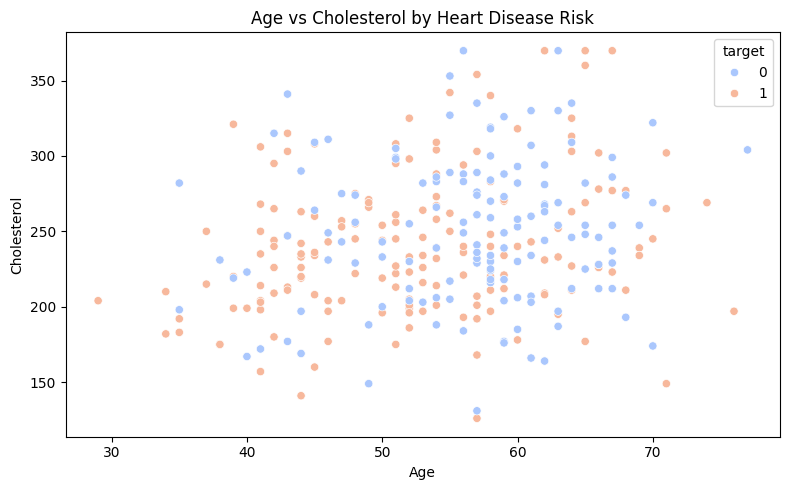

In [7]:
# Scatterplot: Age vs Cholesterol
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="chol", hue="target", palette="coolwarm")
plt.title("Age vs Cholesterol by Heart Disease Risk")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

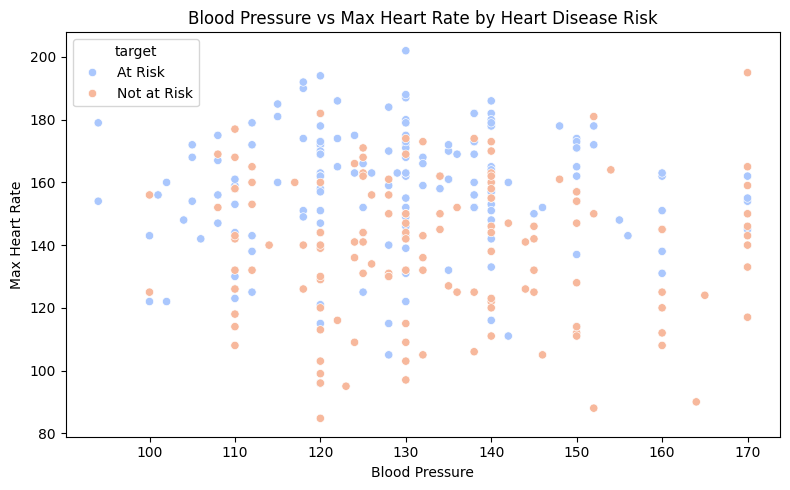

In [8]:
# Scatterplot: Trtbps vs Thalachh
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="trtbps", y="thalachh",
                hue=df["target"].map({0: "Not at Risk", 1: "At Risk"}),
                palette="coolwarm")
plt.title("Blood Pressure vs Max Heart Rate by Heart Disease Risk")
plt.xlabel("Blood Pressure")
plt.ylabel("Max Heart Rate")
plt.tight_layout()
plt.show()

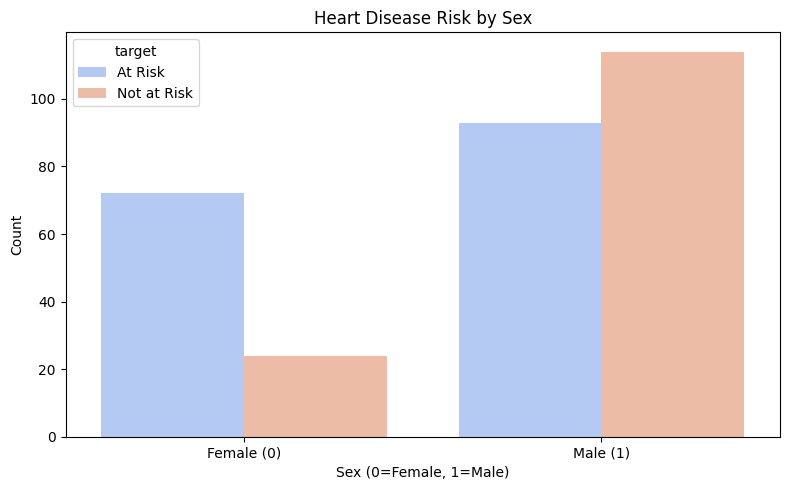

In [9]:
# Count plot — shows number of at risk vs not at risk by sex
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sex",
              hue=df["target"].map({0: "Not at Risk", 1: "At Risk"}),
              palette="coolwarm")
plt.title("Heart Disease Risk by Sex")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.xticks([0, 1], ["Female (0)", "Male (1)"])
plt.ylabel("Count")
plt.tight_layout()
plt.show()

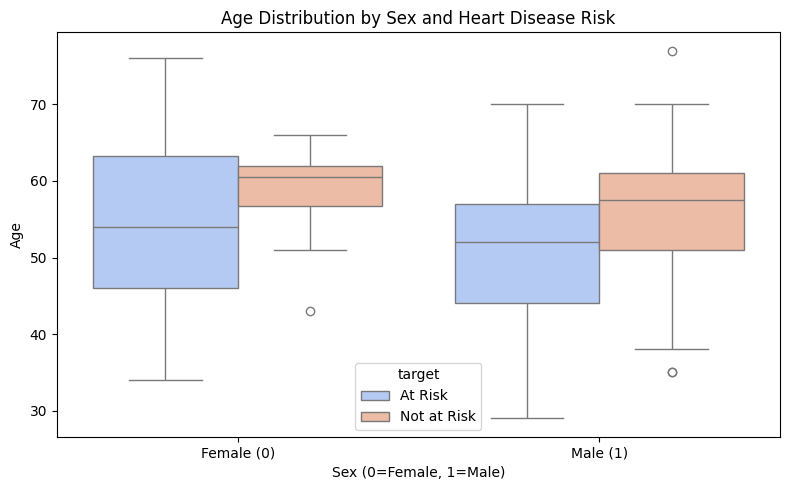

In [10]:
# Age distribution by sex and risk — shows age spread for each group
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sex", y="age",
            hue=df["target"].map({0: "Not at Risk", 1: "At Risk"}),
            palette="coolwarm")
plt.title("Age Distribution by Sex and Heart Disease Risk")
plt.xlabel("Sex (0=Female, 1=Male)")
plt.xticks([0, 1], ["Female (0)", "Male (1)"])
plt.ylabel("Age")
plt.tight_layout()
plt.show()

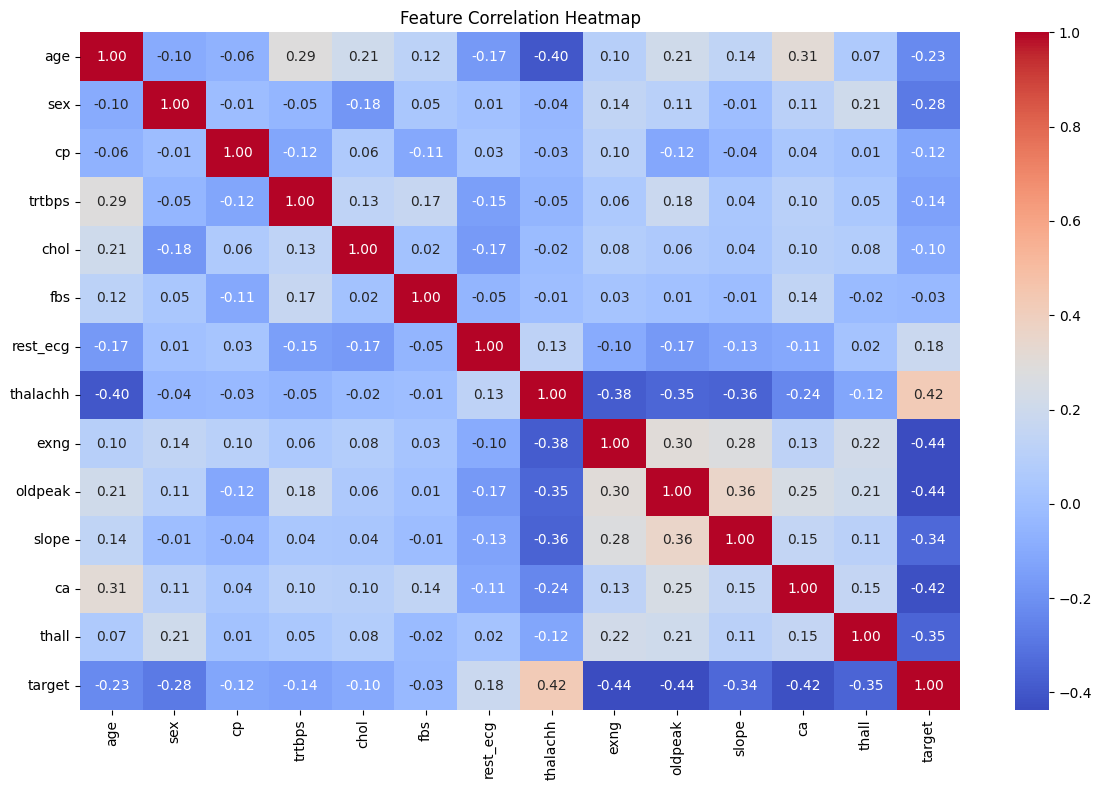

In [11]:
# Correlation heatmap to see relationships between features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Decision Tree Classifier

In [12]:
# Train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 242, Test samples: 61


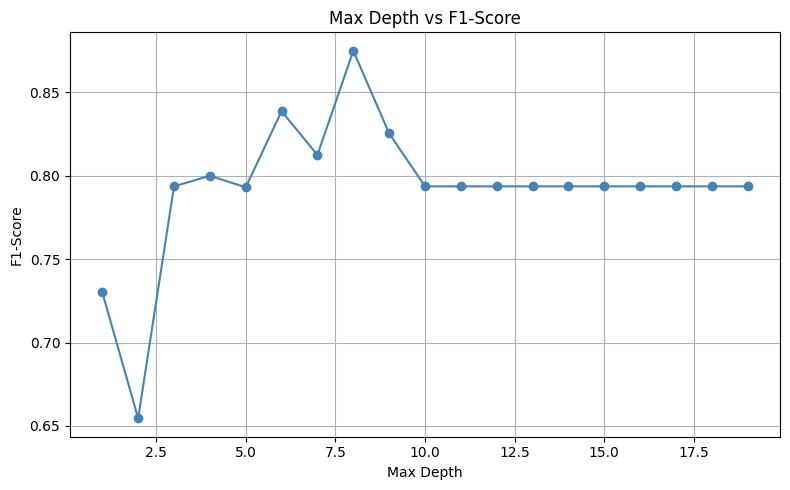

Optimal Max Depth: 8 with F1-Score: 0.8750


In [13]:
# Train decision tree with varying max_depth and evaluate F1-score
depths = range(1, 20)
f1_scores = []

# Loop through depths to find the optimal max depth
for depth in depths:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1_scores.append(f1_score(y_test, preds))

# Plot depth vs F1-score
plt.figure(figsize=(8, 5))
plt.plot(depths, f1_scores, marker="o", color="steelblue")
plt.title("Max Depth vs F1-Score")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Find optimal depth
optimal_depth = depths[f1_scores.index(max(f1_scores))]
print(f"Optimal Max Depth: {optimal_depth} with F1-Score: {max(f1_scores):.4f}")



In [14]:
# Compare depth complexity and F1-score for selected depths
print("--- Depth Complexity Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model_test.fit(X_train, y_train)
    preds = model_test.predict(X_test)
    leaves = model_test.get_n_leaves()
    f1 = f1_score(y_test, preds)
    print(f"Depth: {depth} | Leaves: {leaves} | F1: {f1:.4f}")

--- Depth Complexity Comparison ---
Depth: 3 | Leaves: 8 | F1: 0.7937
Depth: 4 | Leaves: 13 | F1: 0.8000
Depth: 5 | Leaves: 21 | F1: 0.7931
Depth: 6 | Leaves: 30 | F1: 0.8387
Depth: 7 | Leaves: 36 | F1: 0.8125
Depth: 8 | Leaves: 40 | F1: 0.8750
Depth: 9 | Leaves: 43 | F1: 0.8254
Depth: 10 | Leaves: 45 | F1: 0.7937


In [15]:
# Cross-validation to compare depth performance
print("--- Cross Validation Depth Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    cv_scores = cross_val_score(model_test, X, y, cv=5, scoring="f1")
    print(f"Depth: {depth} | Mean F1: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

--- Cross Validation Depth Comparison ---
Depth: 3 | Mean F1: 0.7985 | Std: 0.0425
Depth: 4 | Mean F1: 0.7522 | Std: 0.0321
Depth: 5 | Mean F1: 0.7651 | Std: 0.0393
Depth: 6 | Mean F1: 0.7513 | Std: 0.0271
Depth: 7 | Mean F1: 0.7563 | Std: 0.0373
Depth: 8 | Mean F1: 0.7293 | Std: 0.0300
Depth: 9 | Mean F1: 0.7467 | Std: 0.0283
Depth: 10 | Mean F1: 0.7408 | Std: 0.0405


In [16]:
# Choose optimal depth = 3 based on cross validation results
optimal_depth = 3

# Train final model with optimal depth and evaluate on test set
model = DecisionTreeClassifier(criterion="entropy", max_depth=optimal_depth, random_state=42)
model.fit(X_train, y_train)
print(f"Model retrained with max_depth={optimal_depth}")

Model retrained with max_depth=3


In [17]:
y_pred = model.predict(X_test)

# Evaluate final model performance
print("--- Model Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
      target_names=["Not at Risk", "At Risk"]))

--- Model Evaluation ---
Accuracy:  0.7869
F1-Score:  0.7937
Precision: 0.8065
Recall:    0.7812

--- Classification Report ---
              precision    recall  f1-score   support

 Not at Risk       0.77      0.79      0.78        29
     At Risk       0.81      0.78      0.79        32

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



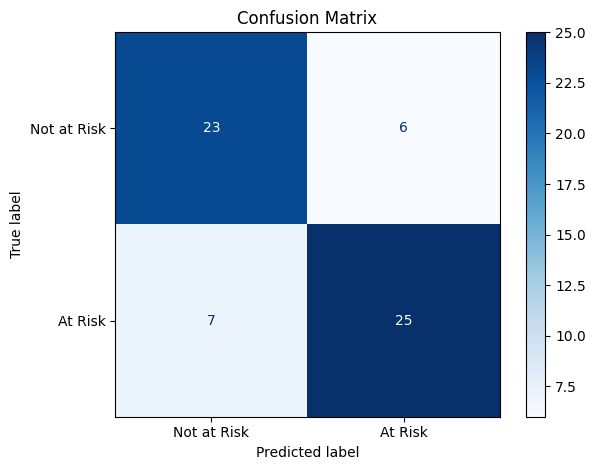

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not at Risk", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
# Confusion matrix values
TN = 23  # True Negatives
FP = 6   # False Positives
FN = 7   # False Negatives
TP = 25  # True Positives

# Total patients
total = TN + FP + FN + TP

# Accuracy
accuracy = (TP + TN) / total

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Specificity (True Negative Rate)
specificity = TN / (TN + FP)

# False Positive Rate
fpr = FP / (FP + TN)

# False Negative Rate
fnr = FN / (FN + TP)

# Error Rate
error_rate = (FP + FN) / total

print("\n" + "=" * 45)
print("            SUMMARY TABLE")
print("=" * 45)
print(f"{'Metric':<30} {'Value':>8} {'Percentage':>12}")
print("-" * 45)
print(f"{'Accuracy':<30} {accuracy:>8.4f} {accuracy*100:>11.1f}%")
print(f"{'Precision':<30} {precision:>8.4f} {precision*100:>11.1f}%")
print(f"{'Recall (Sensitivity)':<30} {recall:>8.4f} {recall*100:>11.1f}%")
print(f"{'F1-Score':<30} {f1:>8.4f} {f1*100:>11.1f}%")
print(f"{'Specificity':<30} {specificity:>8.4f} {specificity*100:>11.1f}%")
print(f"{'False Positive Rate':<30} {fpr:>8.4f} {fpr*100:>11.1f}%")
print(f"{'False Negative Rate':<30} {fnr:>8.4f} {fnr*100:>11.1f}%")
print(f"{'Error Rate':<30} {error_rate:>8.4f} {error_rate*100:>11.1f}%")

print("\n" + "=" * 45)
print("         CLINICAL INTERPRETATION")
print("=" * 45)
print(f"\nTotal patients tested:      {total}")
print(f"Correctly classified:       {TP + TN} ({((TP+TN)/total)*100:.1f}%)")
print(f"Incorrectly classified:     {FP + FN} ({((FP+FN)/total)*100:.1f}%)")
print(f"\nOf {TP+FN} actual at risk patients:")
print(f"  Correctly caught:         {TP} ({recall*100:.1f}%)")
print(f"  Missed (False Negatives): {FN} ({fnr*100:.1f}%)")
print(f"\nOf {TN+FP} actual not at risk patients:")
print(f"  Correctly cleared:        {TN} ({specificity*100:.1f}%)")
print(f"  False alarms:             {FP} ({fpr*100:.1f}%)")


            SUMMARY TABLE
Metric                            Value   Percentage
---------------------------------------------
Accuracy                         0.7869        78.7%
Precision                        0.8065        80.6%
Recall (Sensitivity)             0.7812        78.1%
F1-Score                         0.7937        79.4%
Specificity                      0.7931        79.3%
False Positive Rate              0.2069        20.7%
False Negative Rate              0.2188        21.9%
Error Rate                       0.2131        21.3%

         CLINICAL INTERPRETATION

Total patients tested:      61
Correctly classified:       48 (78.7%)
Incorrectly classified:     13 (21.3%)

Of 32 actual at risk patients:
  Correctly caught:         25 (78.1%)
  Missed (False Negatives): 7 (21.9%)

Of 29 actual not at risk patients:
  Correctly cleared:        23 (79.3%)
  False alarms:             6 (20.7%)


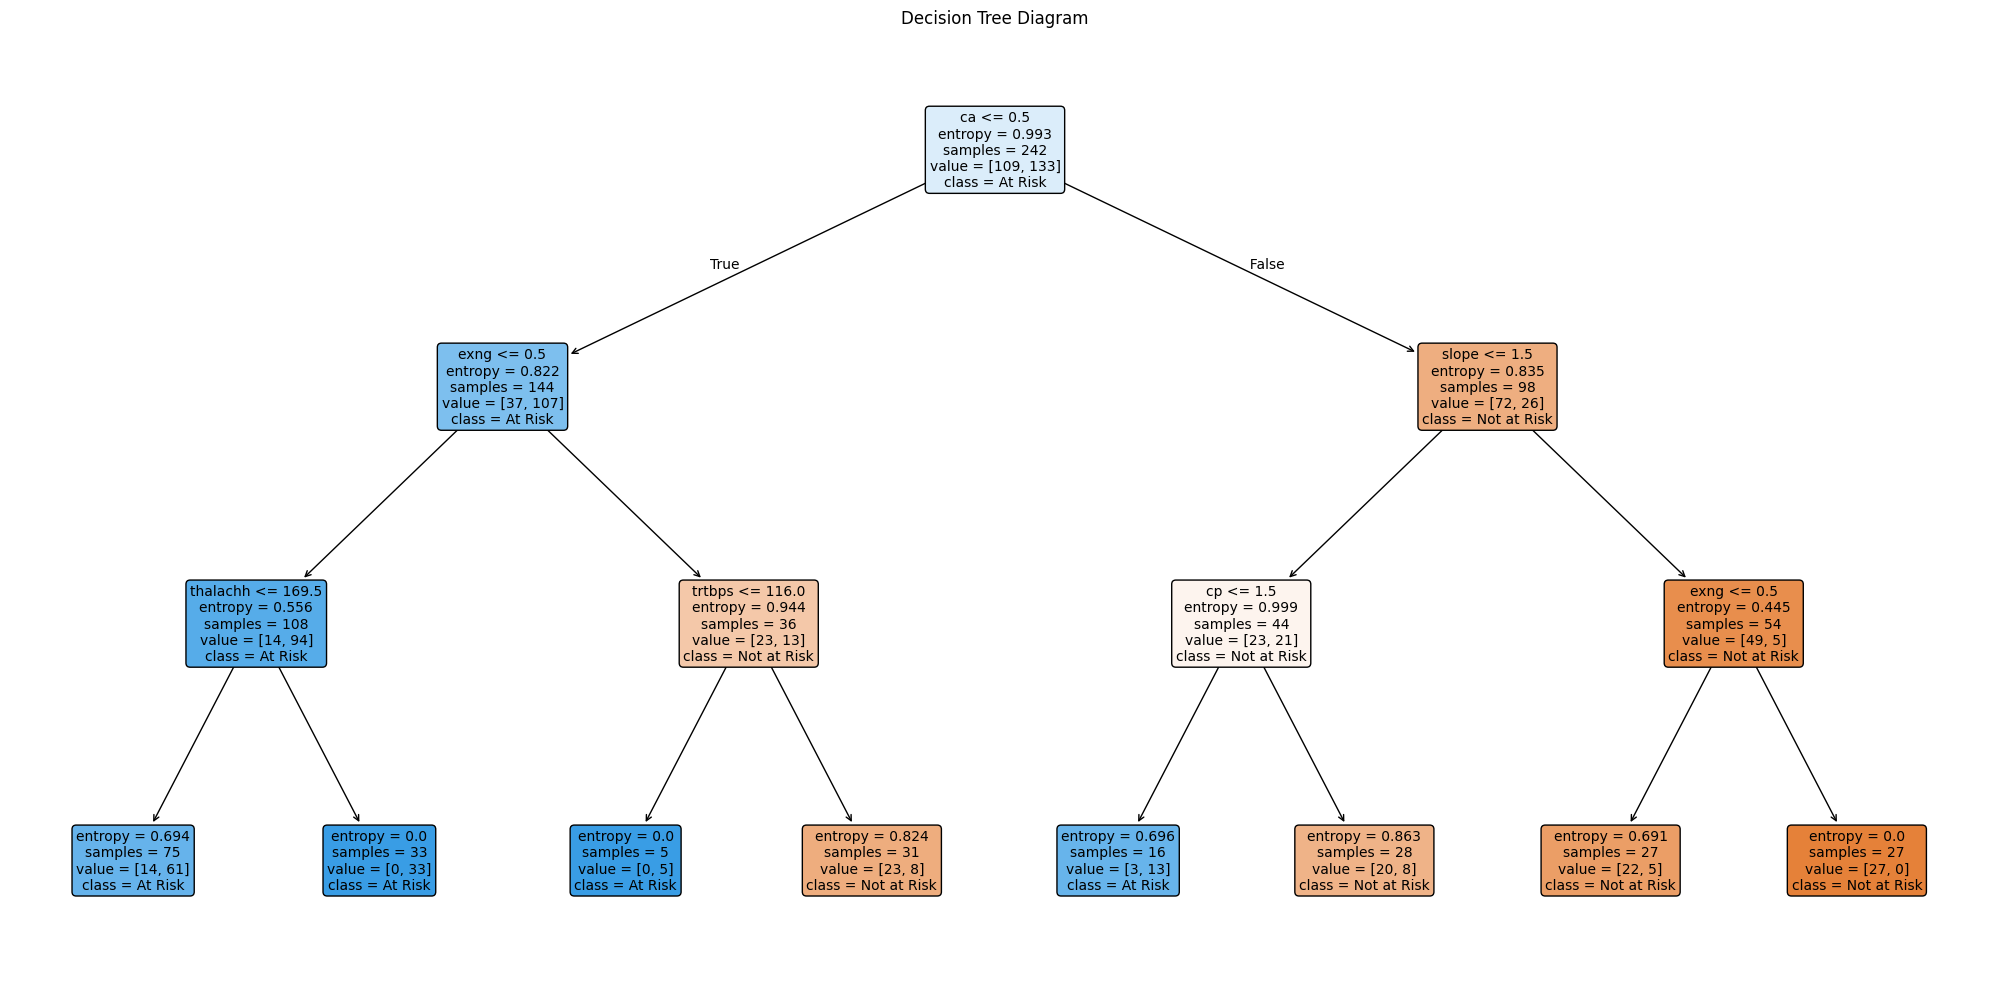

In [20]:
# Decision Tree Diagram
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not at Risk", "At Risk"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Diagram")
plt.tight_layout()
plt.show()

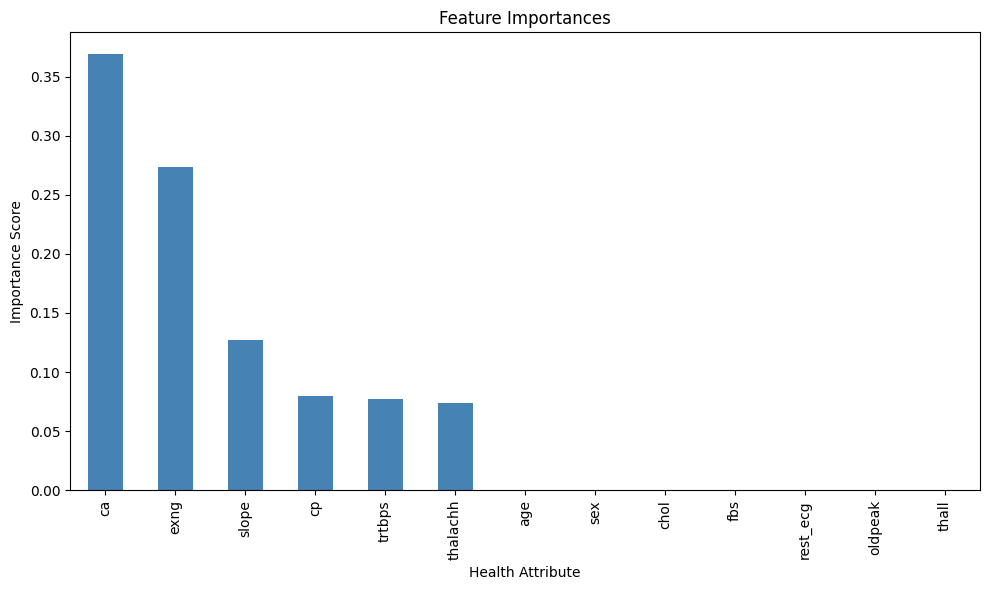

In [21]:
# Feature importance bar chart at optimal depth
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar", color="steelblue")
plt.title("Feature Importances")
plt.xlabel("Health Attribute")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

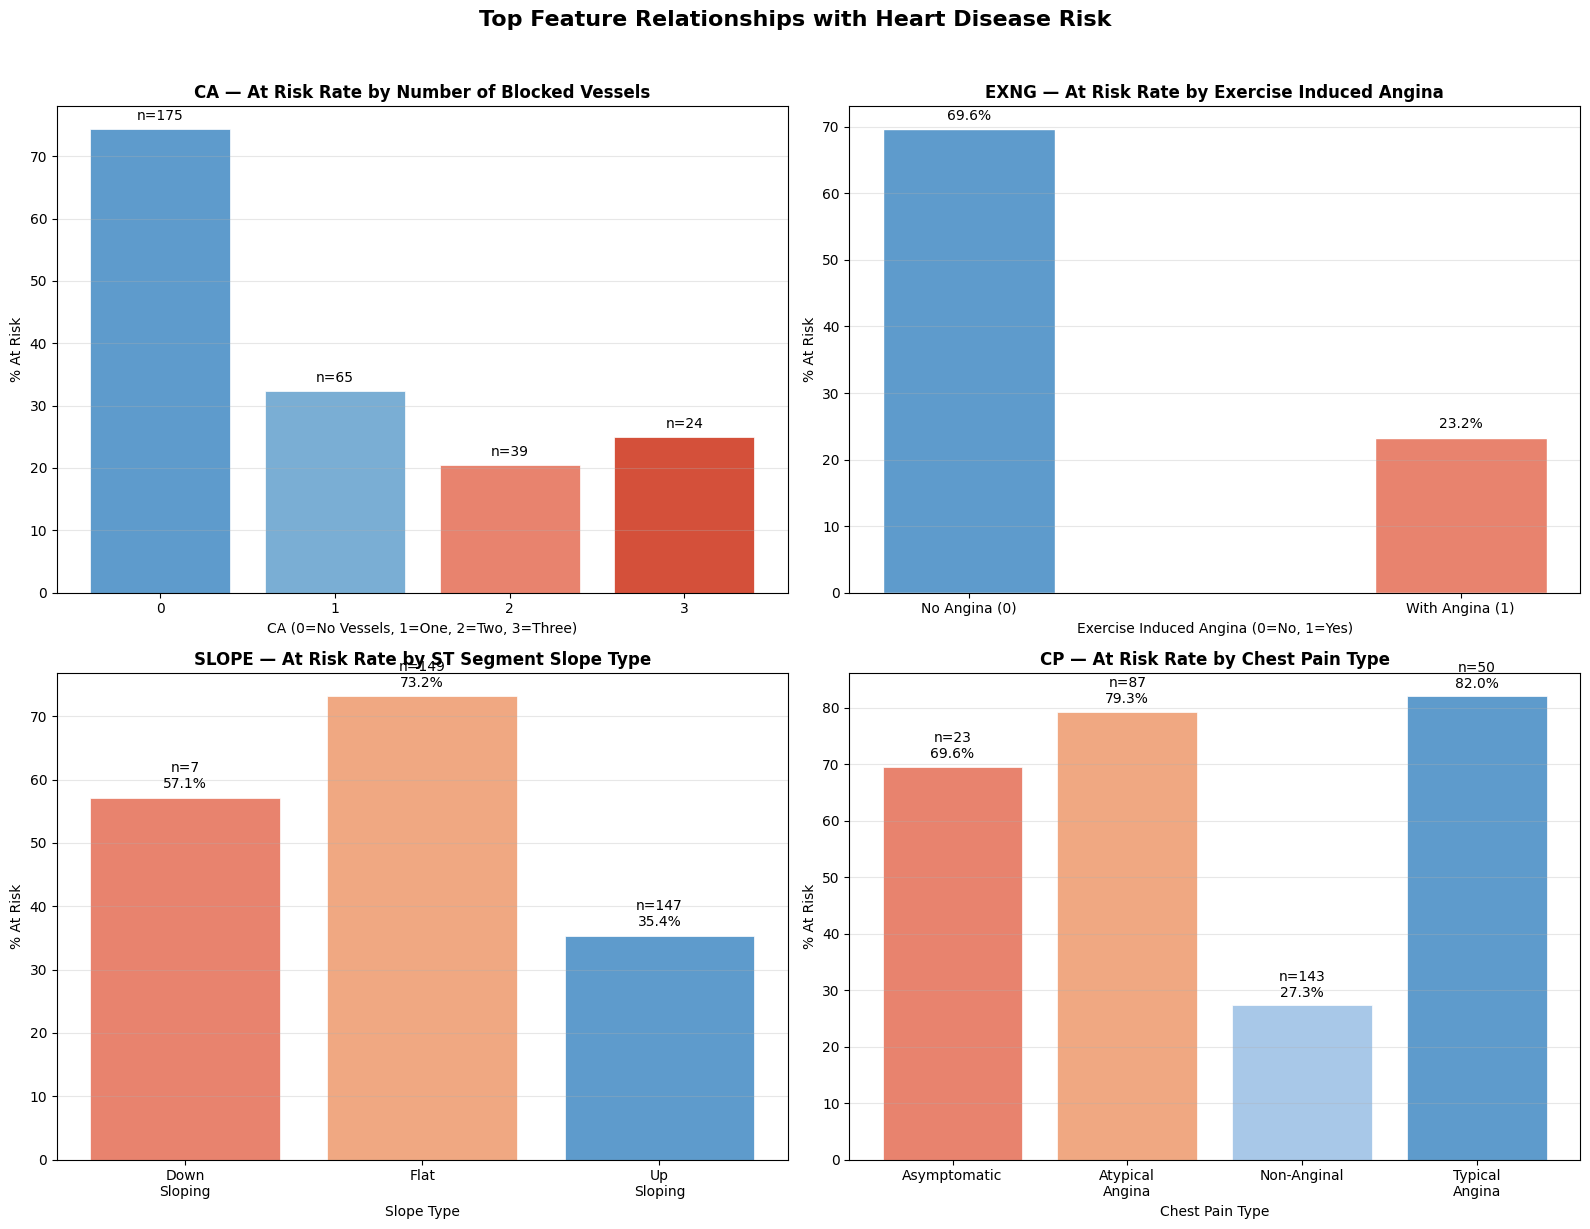

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Top Feature Relationships with Heart Disease Risk", 
             fontsize=16, fontweight="bold", y=1.02)

palette    = {0: "#5e9bcc", 1: "#e8836e"}
risk_label = df["target"].map({0: "Not at Risk", 1: "At Risk"})

# CA vs At Risk Rate
# Shows how risk increases with number of blocked vessels
ca_risk = df.groupby("ca")["target"].mean().reset_index()
ca_risk["target"] = ca_risk["target"] * 100
ca_counts = df.groupby("ca").size().reset_index(name="count")

bars = axes[0, 0].bar(ca_risk["ca"], ca_risk["target"],
                       color=["#5e9bcc", "#7aaed4", "#e8836e", "#d4503a"],
                       edgecolor="white", linewidth=0.5)

# Add count labels on each bar
for i, (bar, count) in enumerate(zip(bars, ca_counts["count"])):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'n={count}', ha="center",
                    va="bottom", fontsize=10)

axes[0, 0].set_title("CA — At Risk Rate by Number of Blocked Vessels",
                      fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("CA (0=No Vessels, 1=One, 2=Two, 3=Three)")
axes[0, 0].set_ylabel("% At Risk")
axes[0, 0].set_xticks([0, 1, 2, 3])
axes[0, 0].grid(axis="y", alpha=0.3)

# EXNG and SLOPE vs At Risk Rate
# Shows how exercise angina and slope type relate to risk
exng_risk  = df.groupby("exng")["target"].mean().reset_index()
slope_risk = df.groupby("slope")["target"].mean().reset_index()
exng_risk["target"]  = exng_risk["target"]  * 100
slope_risk["target"] = slope_risk["target"] * 100

x = np.arange(2)
width  = 0.35

bars1 = axes[0, 1].bar(x - width/2,
                        exng_risk["target"],
                        width, label="Exercise Angina",
                        color=["#5e9bcc", "#e8836e"],
                        edgecolor="white")

# Add percentage labels
for bar in bars1:
    axes[0, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'{bar.get_height():.1f}%',
                    ha="center", va="bottom", fontsize=10)

axes[0, 1].set_title("EXNG — At Risk Rate by Exercise Induced Angina",
                      fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Exercise Induced Angina (0=No, 1=Yes)")
axes[0, 1].set_ylabel("% At Risk")
axes[0, 1].set_xticks(x - width/2)
axes[0, 1].set_xticklabels(["No Angina (0)", "With Angina (1)"])
axes[0, 1].grid(axis="y", alpha=0.3)

# SLOPE vs At Risk Rate
# Shows how ST segment slope type relates to risk
slope_labels = {0: "Down\nSloping", 1: "Flat", 2: "Up\nSloping"}
slope_colors = ["#e8836e", "#f0a882", "#5e9bcc"]
slope_counts = df.groupby("slope").size().reset_index(name="count")

bars3 = axes[1, 0].bar(slope_risk["slope"],
                        slope_risk["target"],
                        color=slope_colors,
                        edgecolor="white", linewidth=0.5)

# Add count and percentage labels
for i, (bar, count) in enumerate(zip(bars3, slope_counts["count"])):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'n={count}\n{bar.get_height():.1f}%',
                    ha="center", va="bottom", fontsize=10)

axes[1, 0].set_title("SLOPE — At Risk Rate by ST Segment Slope Type",
                      fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Slope Type")
axes[1, 0].set_ylabel("% At Risk")
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_xticklabels([slope_labels[i] for i in [0, 1, 2]])
axes[1, 0].grid(axis="y", alpha=0.3)

# CP and TRTBPS vs Target
# Shows chest pain type and blood pressure relationship with risk
cp_risk = df.groupby("cp")["target"].mean().reset_index()
cp_risk["target"] = cp_risk["target"] * 100
cp_counts = df.groupby("cp").size().reset_index(name="count")

cp_labels = {0: "Asymptomatic", 
             1: "Atypical\nAngina",
             2: "Non-Anginal", 
             3: "Typical\nAngina"}
cp_colors = ["#e8836e", "#f0a882", "#a8c8e8", "#5e9bcc"]

bars4 = axes[1, 1].bar(cp_risk["cp"],
                        cp_risk["target"],
                        color=cp_colors,
                        edgecolor="white", linewidth=0.5)

# Add count and percentage labels
for i, (bar, count) in enumerate(zip(bars4, cp_counts["count"])):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1,
                    f'n={count}\n{bar.get_height():.1f}%',
                    ha="center", va="bottom", fontsize=10)

axes[1, 1].set_title("CP — At Risk Rate by Chest Pain Type",
                      fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Chest Pain Type")
axes[1, 1].set_ylabel("% At Risk")
axes[1, 1].set_xticks([0, 1, 2, 3])
axes[1, 1].set_xticklabels([cp_labels[i] for i in [0, 1, 2, 3]])
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

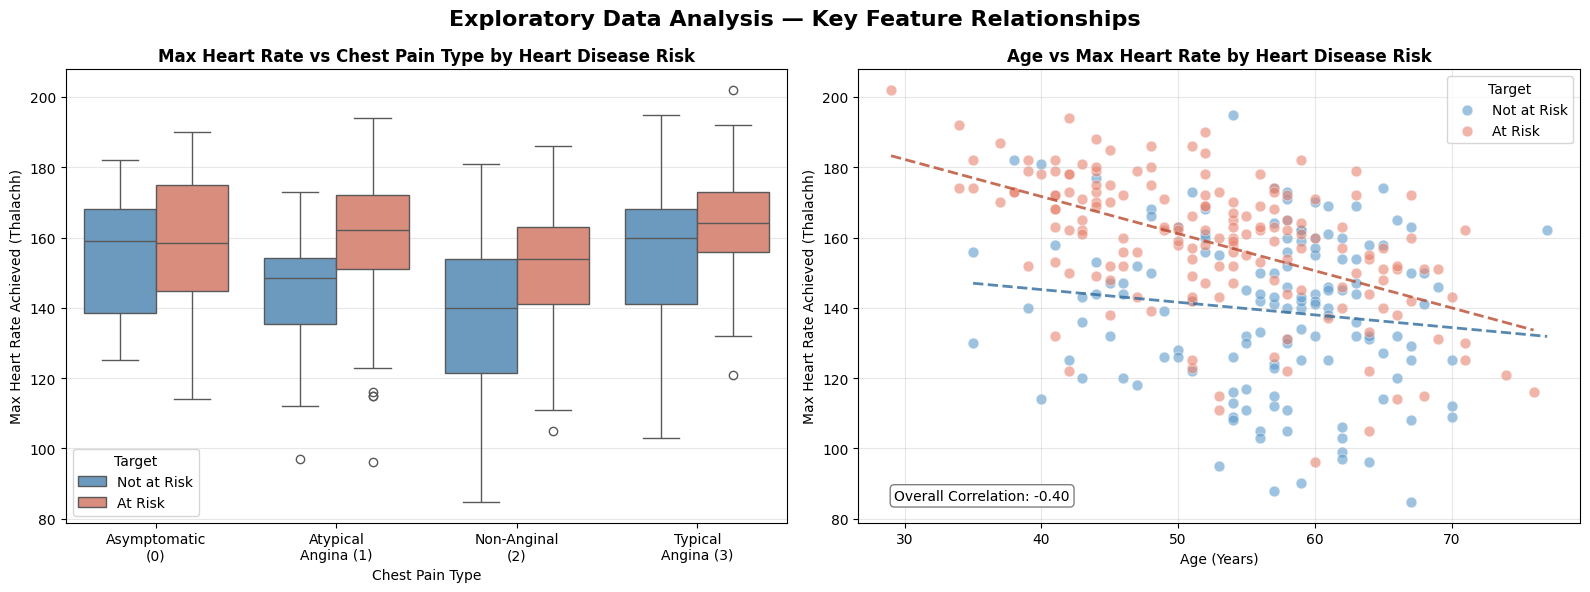

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Exploratory Data Analysis — Key Feature Relationships",
             fontsize=16, fontweight="bold")

palette = {0: "#5e9bcc", 1: "#e8836e"}

# Box Plot — Thalachh vs CP by Target
sns.boxplot(
    data=df, x="cp", y="thalachh", hue="target",
    palette=palette, hue_order=[0, 1], ax=axes[0]
)
axes[0].set_title("Max Heart Rate vs Chest Pain Type by Heart Disease Risk",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Chest Pain Type")
axes[0].set_ylabel("Max Heart Rate Achieved (Thalachh)")
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(["Asymptomatic\n(0)", "Atypical\nAngina (1)",
                          "Non-Anginal\n(2)", "Typical\nAngina (3)"])
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Not at Risk", "At Risk"], title="Target")
axes[0].grid(axis="y", alpha=0.3)

# Scatter Plot — Age vs Thalachh by Target
for target_val, label, color in zip([0, 1],
                                     ["Not at Risk", "At Risk"],
                                     ["#5e9bcc", "#e8836e"]):
    mask = df["target"] == target_val
    axes[1].scatter(df.loc[mask, "age"],
                    df.loc[mask, "thalachh"],
                    c=color, label=label,
                    alpha=0.6, edgecolors="white",
                    linewidth=0.5, s=60)

# Add trend line for each group
for target_val, color in zip([0, 1], ["#2e6b9c", "#b84a2e"]):
    mask = df["target"] == target_val
    z    = np.polyfit(df.loc[mask, "age"],
                      df.loc[mask, "thalachh"], 1)
    p    = np.poly1d(z)
    x_line = np.linspace(df.loc[mask, "age"].min(),
                          df.loc[mask, "age"].max(), 100)
    axes[1].plot(x_line, p(x_line), color=color,
                 linestyle="--", linewidth=2, alpha=0.8)

axes[1].set_title("Age vs Max Heart Rate by Heart Disease Risk",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Max Heart Rate Achieved (Thalachh)")
axes[1].legend(title="Target")
axes[1].grid(alpha=0.3)

# Add correlation annotation
corr = df["age"].corr(df["thalachh"])
axes[1].annotate(f"Overall Correlation: {corr:.2f}",
                  xy=(0.05, 0.05),
                  xycoords="axes fraction",
                  fontsize=10,
                  bbox=dict(boxstyle="round,pad=0.3",
                            facecolor="white",
                            edgecolor="gray"))

plt.tight_layout()
plt.show()

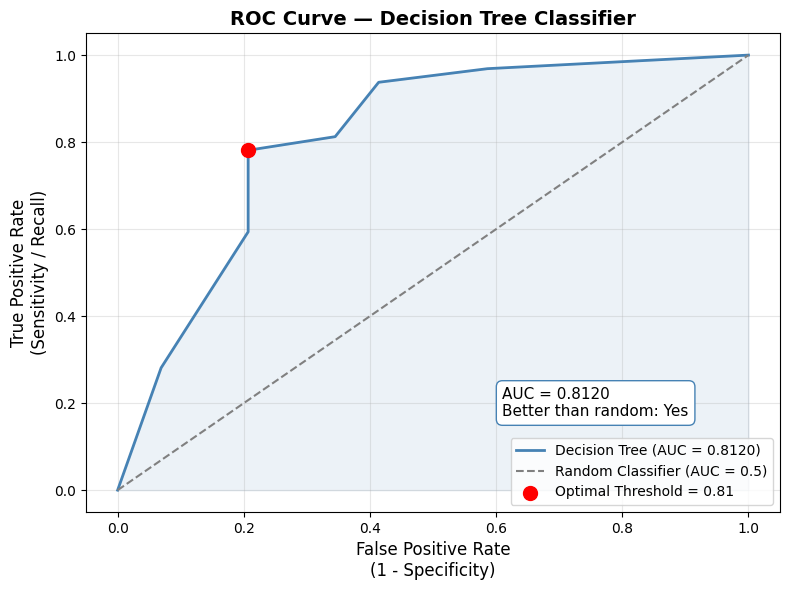


--- ROC Curve Summary ---
AUC Score:         0.8120
Optimal Threshold: 0.8125
At optimal point:
  True Positive Rate:  0.7812
  False Positive Rate: 0.2069


In [24]:
# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))

# ROC Curve line
plt.plot(fpr, tpr, color="steelblue", linewidth=2,
         label=f"Decision Tree (AUC = {auc_score:.4f})")

# Random classifier diagonal line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--",
         linewidth=1.5, label="Random Classifier (AUC = 0.5)")

# Shade area under curve
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")

# Mark the optimal threshold point
optimal_idx = np.argmax(tpr - fpr)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color="red", zorder=5, s=100,
            label=f"Optimal Threshold = "
                  f"{thresholds[optimal_idx]:.2f}")

# Formatting
plt.title("ROC Curve — Decision Tree Classifier",
          fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate\n(1 - Specificity)",
           fontsize=12)
plt.ylabel("True Positive Rate\n(Sensitivity / Recall)",
           fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Add AUC text box
plt.annotate(f"AUC = {auc_score:.4f}\n"
             f"Better than random: "
             f"{'Yes' if auc_score > 0.5 else 'No'}",
             xy=(0.6, 0.2),
             xycoords="axes fraction",
             fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4",
                       facecolor="white",
                       edgecolor="steelblue"))

plt.tight_layout()
plt.show()

# Print summary
print("\n--- ROC Curve Summary ---")
print(f"AUC Score:         {auc_score:.4f}")
print(f"Optimal Threshold: {thresholds[optimal_idx]:.4f}")
print(f"At optimal point:")
print(f"  True Positive Rate:  {tpr[optimal_idx]:.4f}")
print(f"  False Positive Rate: {fpr[optimal_idx]:.4f}")

In [25]:
# Function to predict heart disease risk for new patient data
def predict_heart_disease_risk(model, feature_names, patient_data):
    """
    Predicts heart disease risk using the trained model.
    
    Parameters:
    - model:          Trained decision tree classifier
    - feature_names:  List of feature column names
    - patient_data:   Dictionary of health attribute values
    - patient_label:  Optional label to identify the patient
    
    Returns:
    - prediction:     0 = Not at Risk, 1 = At Risk
    - confidence:     Confidence percentage of prediction
    """
    errors = []
    
    # Check all required features are present
    for feature in feature_names:
        if feature not in patient_data:
            errors.append(f"Missing feature: '{feature}'")
    
    # Check all values are numeric
    for feature, value in patient_data.items():
        try:
            float(value)
        except (ValueError, TypeError):
            errors.append(f"Invalid value for '{feature}': {value} "
                          f"— must be numeric")
    
    # Check value ranges for key features
    validations = {
        "age":      (18,  120, "years"),
        "trtbps":   (50,  250, "mmHg"),
        "chol":     (100, 600, "mg/dL"),
        "thalachh": (60,  220, "bpm"),
        "oldpeak":  (0,   10,  "mm"),
        "ca":       (0,   3,   "vessels"),
        "sex":      (0,   1,   "0=Female 1=Male"),
        "fbs":      (0,   1,   "0=False 1=True"),
        "exng":     (0,   1,   "0=No 1=Yes"),
        "cp":       (0,   3,   "0-3"),
        "rest_ecg": (0,   2,   "0-2"),
        "slope":    (0,   2,   "0-2"),
        "thall":    (1,   3,   "1-3")
    }

    for feature, (min_val, max_val, unit) in validations.items():
        if feature in patient_data:
            value = patient_data[feature]
            if not (min_val <= float(value) <= max_val):
                errors.append(f"'{feature}' value of {value} is outside "
                              f"expected range ({min_val}-{max_val} {unit})")
    
    # Print errors if any and stop
    if errors:
        print(f"\n--- Validation Errors ---")
        for error in errors:
            print(f"  ✗ {error}")
        return None, None
    
    # Create DataFrame for prediction
    input_df   = pd.DataFrame([patient_data])
    prediction  = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]
    confidence  = max(probability) * 100

    # Print patient data and prediction results
    print(f"  Health Attributes:")
    for feature, value in patient_data.items():
        print(f"    {feature:<12}: {value}")
    print(f"\n  Result:     "
          f"{'AT RISK' if prediction == 1 else 'NOT AT RISK'} "
          f"for Heart Disease")
    print(f"  Confidence: {confidence:.1f}%")


In [26]:
# Patient 1 — High Risk Profile
patient_1 = {
    "age":      58,
    "sex":      1,       # Male
    "cp":       0,       # Asymptomatic
    "trtbps":   140,     # Blood pressure
    "chol":     260,     # Cholesterol
    "fbs":      0,       # Normal blood sugar
    "rest_ecg": 1,       # Normal
    "thalachh": 145,     # Low max heart rate <= 169.5
    "exng":     0,       # No exercise angina <= 0.5
    "oldpeak":  1.5,
    "slope":    1,       # Flat
    "ca":       0,       # No vessels blocked <= 0.5
    "thall":    2
}
predict_heart_disease_risk(model, X.columns, patient_1)

  Health Attributes:
    age         : 58
    sex         : 1
    cp          : 0
    trtbps      : 140
    chol        : 260
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 145
    exng        : 0
    oldpeak     : 1.5
    slope       : 1
    ca          : 0
    thall       : 2

  Result:     AT RISK for Heart Disease
  Confidence: 81.3%


In [27]:
# Patient 2 — Low Risk Profile
patient_2 = {
    "age":      45,
    "sex":      0,       # Female
    "cp":       2,       # Non-Anginal
    "trtbps":   125,     # Normal blood pressure
    "chol":     210,     # Normal cholesterol
    "fbs":      0,       # Normal blood sugar
    "rest_ecg": 1,       # Normal
    "thalachh": 165,     # Normal heart rate
    "exng":     0,       # No exercise angina <= 0.5
    "oldpeak":  0.5,
    "slope":    2,       # Up Sloping > 1.5
    "ca":       2,       # Two vessels > 0.5
    "thall":    1
}

predict_heart_disease_risk(model, X.columns, patient_2)

  Health Attributes:
    age         : 45
    sex         : 0
    cp          : 2
    trtbps      : 125
    chol        : 210
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 165
    exng        : 0
    oldpeak     : 0.5
    slope       : 2
    ca          : 2
    thall       : 1

  Result:     NOT AT RISK for Heart Disease
  Confidence: 81.5%


In [28]:
# Patient 3 — Borderline Profile
patient_3 = {
    "age":      52,
    "sex":      1,       # Male
    "cp":       1,       # Atypical Angina
    "trtbps":   145,     # High blood pressure > 116
    "chol":     230,     # Borderline cholesterol
    "fbs":      1,       # High blood sugar
    "rest_ecg": 0,       # LV Hypertrophy
    "thalachh": 158,     # Average heart rate
    "exng":     1,       # With exercise angina > 0.5
    "oldpeak":  2.1,
    "slope":    1,       # Flat
    "ca":       0,       # No vessels blocked <= 0.5
    "thall":    2
}
predict_heart_disease_risk(model, X.columns, patient_3)

  Health Attributes:
    age         : 52
    sex         : 1
    cp          : 1
    trtbps      : 145
    chol        : 230
    fbs         : 1
    rest_ecg    : 0
    thalachh    : 158
    exng        : 1
    oldpeak     : 2.1
    slope       : 1
    ca          : 0
    thall       : 2

  Result:     NOT AT RISK for Heart Disease
  Confidence: 74.2%


## Data Alteration

In [29]:
df_altered = df.copy()

df_altered.info()
df_altered.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    float64
 5   fbs       303 non-null    int64  
 6   rest_ecg  303 non-null    int64  
 7   thalachh  303 non-null    float64
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thall     303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,age,sex,cp,trtbps,chol,fbs,rest_ecg,thalachh,exng,oldpeak,slope,ca,thall,target
0,63,1,0,145,233.0,1,1,150.0,0,2.3,1,0,1,1
1,37,1,1,130,250.0,0,2,187.0,0,3.5,2,0,2,1
2,41,0,3,130,204.0,0,1,172.0,0,1.4,1,0,2,1
3,56,1,3,120,236.0,0,2,178.0,0,0.8,1,0,2,1
4,57,0,2,120,354.0,0,2,163.0,1,0.6,1,0,2,1
5,57,1,2,140,192.0,0,2,148.0,0,0.4,2,0,1,1
6,56,0,3,140,294.0,0,1,153.0,0,1.3,2,0,2,1
7,44,1,3,120,263.0,0,2,173.0,0,0.0,1,0,3,1
8,52,1,1,170,199.0,1,2,162.0,0,0.5,1,0,3,1
9,57,1,1,150,168.0,0,2,174.0,0,1.6,1,0,2,1


In [30]:
# Create masks for at risk and not at risk patients
at_risk_mask = df_altered["target"] == 1
not_at_risk_mask = df_altered["target"] == 0


# Apply the changes to the 'chol' column based on the masks
# Increase at risk cholesterol by 15% with random noise
noise_at_risk = np.random.normal(0, 10,
                at_risk_mask.sum())
df_altered.loc[at_risk_mask, "chol"] = (
    df_altered.loc[at_risk_mask, "chol"] * 1.15
    + noise_at_risk
).round().astype(int)

# Decrease not at risk cholesterol by 10% with random noise
noise_not_at_risk = np.random.normal(0, 10,
                    not_at_risk_mask.sum())
df_altered.loc[not_at_risk_mask, "chol"] = (
    df_altered.loc[not_at_risk_mask, "chol"] * 0.90
    + noise_not_at_risk
).round().astype(int)

df_altered.head(10)

print("=== ORIGINAL CHOLESTEROL STATS ===")
print(f"At Risk     mean: "
      f"{df[df['target']==1]['chol'].mean():.2f}")
print(f"Not at Risk mean: "
      f"{df[df['target']==0]['chol'].mean():.2f}")
print(f"Original correlation with target: "
      f"{df['chol'].corr(df['target']):.4f}")

print("\n=== ALTERED CHOLESTEROL STATS ===")
print(f"At Risk     mean: "
      f"{df_altered[df_altered['target']==1]['chol'].mean():.2f}")
print(f"Not at Risk mean: "
      f"{df_altered[df_altered['target']==0]['chol'].mean():.2f}")
print(f"New correlation with target: "
      f"{df_altered['chol'].corr(df_altered['target']):.4f}")

=== ORIGINAL CHOLESTEROL STATS ===
At Risk     mean: 240.62
Not at Risk mean: 250.53
Original correlation with target: -0.1040

=== ALTERED CHOLESTEROL STATS ===
At Risk     mean: 276.59
Not at Risk mean: 226.87
New correlation with target: 0.4446


In [31]:
# Define X and y (altered)
X_altered = df_altered.drop("target", axis=1)
y_altered = df_altered["target"]

# Check class distribution after alteration
altered_class_counts = y_altered.value_counts()
altered_class_pct    = y_altered.value_counts(normalize=True) * 100

print("\nClass Distribution after alteration:")
print(f"Not at Risk: {altered_class_counts[0]} patients ({altered_class_pct[0]:.1f}%)")
print(f"At Risk:     {altered_class_counts[1]} patients ({altered_class_pct[1]:.1f}%)")
print(f"Imbalance Ratio: {altered_class_counts[0]/altered_class_counts[1]:.2f}:1")


Class Distribution after alteration:
Not at Risk: 138 patients (45.5%)
At Risk:     165 patients (54.5%)
Imbalance Ratio: 0.84:1


In [32]:
# Train/test split
X_train_altered, X_test_altered, y_train_altered, y_test_altered = train_test_split(
    X_altered, y_altered, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train_altered)}, Test samples: {len(X_test_altered)}")

Training samples: 242, Test samples: 61


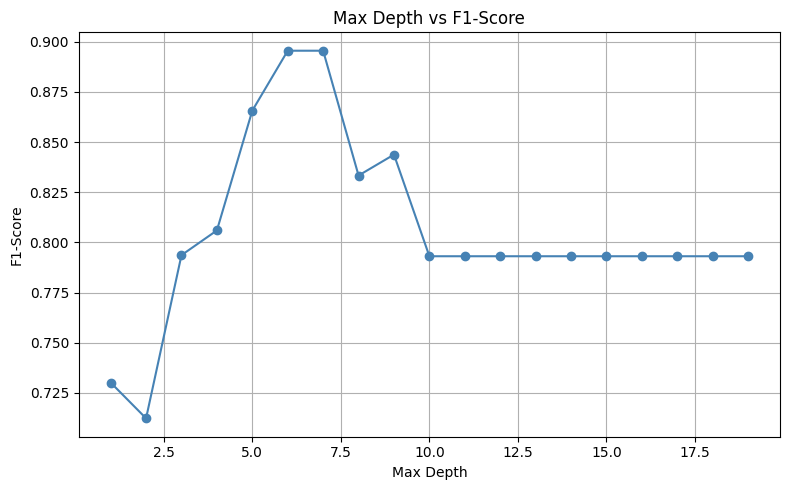

Optimal Max Depth: 6 with F1-Score: 0.8955
--- Depth Complexity Comparison ---
Depth: 3 | Leaves: 8 | F1: 0.7937
Depth: 4 | Leaves: 12 | F1: 0.8060
Depth: 5 | Leaves: 18 | F1: 0.8657
Depth: 6 | Leaves: 23 | F1: 0.8955
Depth: 7 | Leaves: 28 | F1: 0.8955
Depth: 8 | Leaves: 30 | F1: 0.8333
Depth: 9 | Leaves: 32 | F1: 0.8438
Depth: 10 | Leaves: 32 | F1: 0.7931

--- Cross Validation Depth Comparison ---
Depth: 3 | Mean F1: 0.7626 | Std: 0.0384
Depth: 4 | Mean F1: 0.7713 | Std: 0.0475
Depth: 5 | Mean F1: 0.7677 | Std: 0.0339
Depth: 6 | Mean F1: 0.7885 | Std: 0.0415
Depth: 7 | Mean F1: 0.7566 | Std: 0.0392
Depth: 8 | Mean F1: 0.7509 | Std: 0.0416
Depth: 9 | Mean F1: 0.7744 | Std: 0.0599
Depth: 10 | Mean F1: 0.7706 | Std: 0.0564


In [33]:
# Train decision tree with varying max_depth and evaluate F1-score
depths = range(1, 20)
f1_scores = []

# Loop through depths to find the optimal max depth
for depth in depths:
    model_altered = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model_altered.fit(X_train_altered, y_train_altered)
    preds = model_altered.predict(X_test_altered)
    f1_scores.append(f1_score(y_test_altered, preds))

# Plot depth vs F1-score
plt.figure(figsize=(8, 5))
plt.plot(depths, f1_scores, marker="o", color="steelblue")
plt.title("Max Depth vs F1-Score")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Find optimal depth
optimal_depth = depths[f1_scores.index(max(f1_scores))]
print(f"Optimal Max Depth: {optimal_depth} with F1-Score: {max(f1_scores):.4f}")


# Compare depth complexity and F1-score for selected depths
print("--- Depth Complexity Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_altered_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model_altered_test.fit(X_train_altered, y_train_altered)
    preds = model_altered_test.predict(X_test_altered)
    leaves = model_altered_test.get_n_leaves()
    f1 = f1_score(y_test_altered, preds)
    print(f"Depth: {depth} | Leaves: {leaves} | F1: {f1:.4f}")

# Cross-validation to compare depth performance
print("\n--- Cross Validation Depth Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_altered_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    cv_scores = cross_val_score(model_altered_test, X_altered, y_altered, cv=5, scoring="f1")
    print(f"Depth: {depth} | Mean F1: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

In [34]:
# Choose optimal depth = 3 based on cross validation results
optimal_depth = 3

# Train final altered model with optimal depth and evaluate on test set
model_altered = DecisionTreeClassifier(criterion="entropy", max_depth=optimal_depth, random_state=42)
model_altered.fit(X_train_altered, y_train_altered)
print(f"Altered model retrained with max_depth={optimal_depth}")


Altered model retrained with max_depth=3


In [35]:
y_pred_altered = model_altered.predict(X_test)

# Evaluate final model performance
print("--- Model Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test_altered, y_pred_altered):.4f}")
print(f"F1-Score:  {f1_score(y_test_altered, y_pred_altered):.4f}")
print(f"Precision: {precision_score(y_test_altered, y_pred_altered):.4f}")
print(f"Recall:    {recall_score(y_test_altered, y_pred_altered):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_altered, y_pred_altered,
      target_names=["Not at Risk", "At Risk"]))

--- Model Evaluation ---
Accuracy:  0.7377
F1-Score:  0.7419
Precision: 0.7667
Recall:    0.7188

--- Classification Report ---
              precision    recall  f1-score   support

 Not at Risk       0.71      0.76      0.73        29
     At Risk       0.77      0.72      0.74        32

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



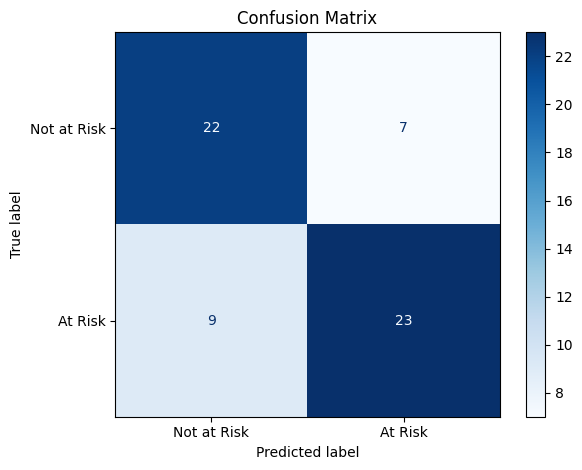

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test_altered, y_pred_altered)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not at Risk", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [37]:
# Confusion matrix values
TN = 23  # True Negatives
FP = 6   # False Positives
FN = 7   # False Negatives
TP = 25  # True Positives

# Total patients
total = TN + FP + FN + TP

# Accuracy
accuracy = (TP + TN) / total

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Specificity (True Negative Rate)
specificity = TN / (TN + FP)

# False Positive Rate
fpr = FP / (FP + TN)

# False Negative Rate
fnr = FN / (FN + TP)

# Error Rate
error_rate = (FP + FN) / total

print("\n" + "=" * 45)
print("            SUMMARY TABLE")
print("=" * 45)
print(f"{'Metric':<30} {'Value':>8} {'Percentage':>12}")
print("-" * 45)
print(f"{'Accuracy':<30} {accuracy:>8.4f} {accuracy*100:>11.1f}%")
print(f"{'Precision':<30} {precision:>8.4f} {precision*100:>11.1f}%")
print(f"{'Recall (Sensitivity)':<30} {recall:>8.4f} {recall*100:>11.1f}%")
print(f"{'F1-Score':<30} {f1:>8.4f} {f1*100:>11.1f}%")
print(f"{'Specificity':<30} {specificity:>8.4f} {specificity*100:>11.1f}%")
print(f"{'False Positive Rate':<30} {fpr:>8.4f} {fpr*100:>11.1f}%")
print(f"{'False Negative Rate':<30} {fnr:>8.4f} {fnr*100:>11.1f}%")
print(f"{'Error Rate':<30} {error_rate:>8.4f} {error_rate*100:>11.1f}%")

print("\n" + "=" * 45)
print("         CLINICAL INTERPRETATION")
print("=" * 45)
print(f"\nTotal patients tested:      {total}")
print(f"Correctly classified:       {TP + TN} ({((TP+TN)/total)*100:.1f}%)")
print(f"Incorrectly classified:     {FP + FN} ({((FP+FN)/total)*100:.1f}%)")
print(f"\nOf {TP+FN} actual at risk patients:")
print(f"  Correctly caught:         {TP} ({recall*100:.1f}%)")
print(f"  Missed (False Negatives): {FN} ({fnr*100:.1f}%)")
print(f"\nOf {TN+FP} actual not at risk patients:")
print(f"  Correctly cleared:        {TN} ({specificity*100:.1f}%)")
print(f"  False alarms:             {FP} ({fpr*100:.1f}%)")


            SUMMARY TABLE
Metric                            Value   Percentage
---------------------------------------------
Accuracy                         0.7869        78.7%
Precision                        0.8065        80.6%
Recall (Sensitivity)             0.7812        78.1%
F1-Score                         0.7937        79.4%
Specificity                      0.7931        79.3%
False Positive Rate              0.2069        20.7%
False Negative Rate              0.2188        21.9%
Error Rate                       0.2131        21.3%

         CLINICAL INTERPRETATION

Total patients tested:      61
Correctly classified:       48 (78.7%)
Incorrectly classified:     13 (21.3%)

Of 32 actual at risk patients:
  Correctly caught:         25 (78.1%)
  Missed (False Negatives): 7 (21.9%)

Of 29 actual not at risk patients:
  Correctly cleared:        23 (79.3%)
  False alarms:             6 (20.7%)


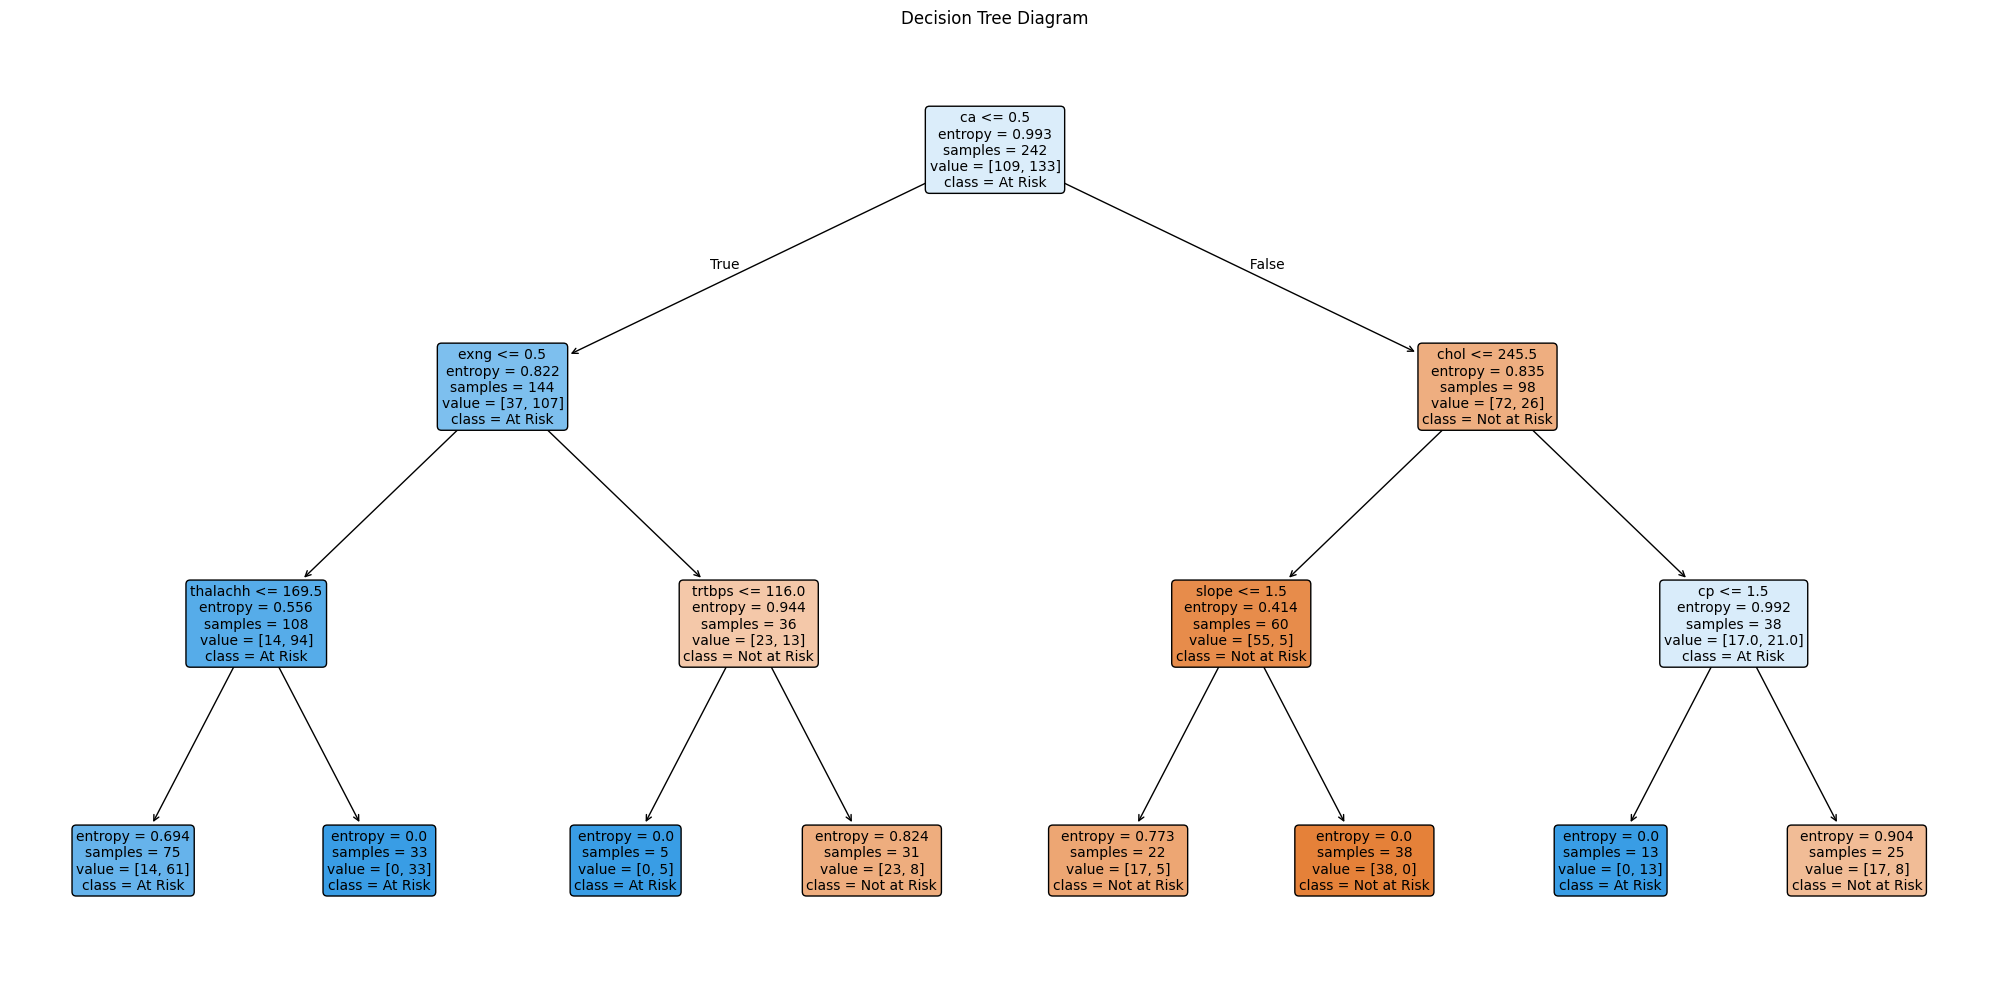

In [38]:
# Decision Tree Diagram
plt.figure(figsize=(20, 10))
plot_tree(
    model_altered,
    feature_names=X.columns,
    class_names=["Not at Risk", "At Risk"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Diagram")
plt.tight_layout()
plt.show()

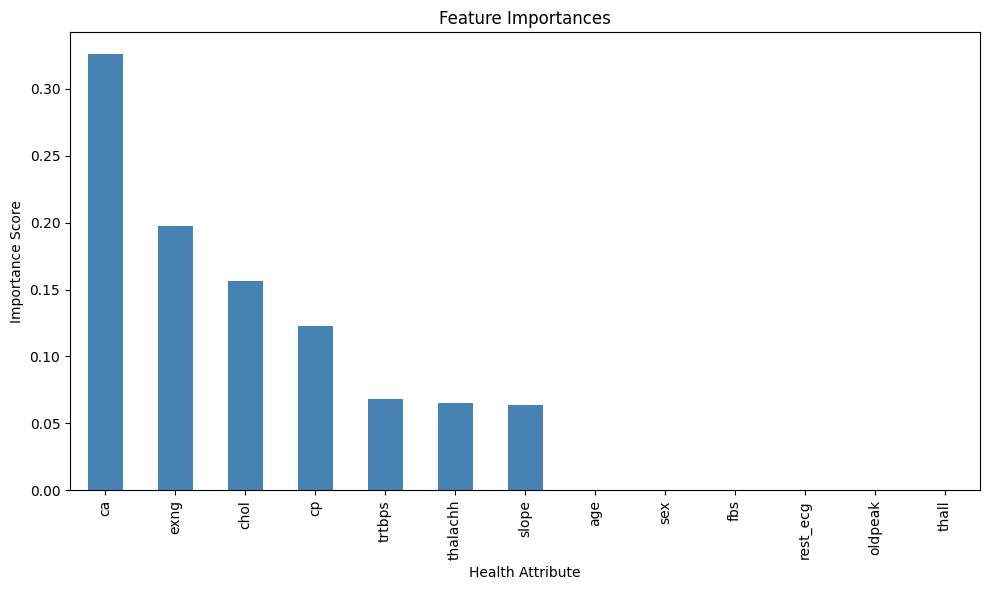

In [39]:
# Feature importance bar chart at optimal depth
importances = pd.Series(model_altered.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar", color="steelblue")
plt.title("Feature Importances")
plt.xlabel("Health Attribute")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

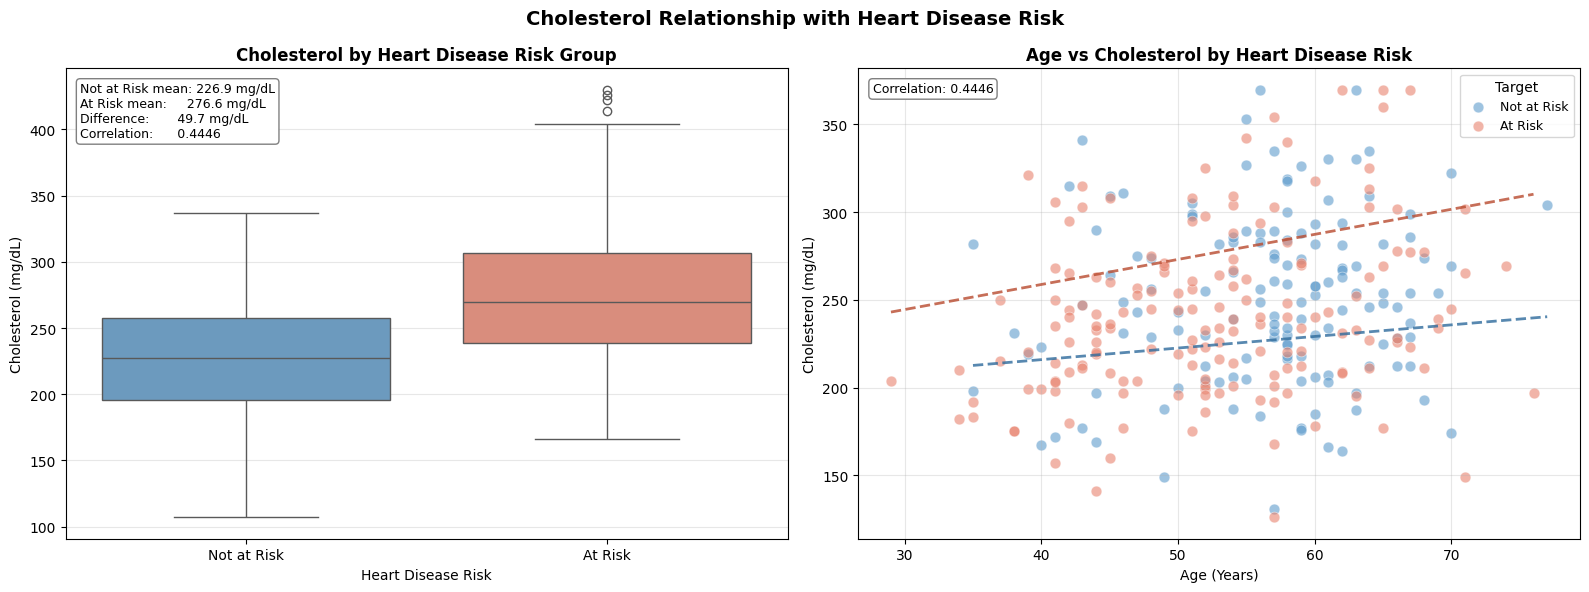

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cholesterol Relationship with Heart Disease Risk",
             fontsize=14, fontweight="bold")

# Box Plot — Cholesterol vs Risk Group
sns.boxplot(
    data=df_altered,
    x=df_altered["target"].map({0: "Not at Risk", 1: "At Risk"}),
    y="chol",
    hue=df_altered["target"].map({0: "Not at Risk", 1: "At Risk"}),
    palette={"Not at Risk": "#5e9bcc", "At Risk": "#e8836e"},
    ax=axes[0],
    order=["Not at Risk", "At Risk"]
)

not_risk_mean = df_altered[df_altered["target"]==0]["chol"].mean()
at_risk_mean  = df_altered[df_altered["target"]==1]["chol"].mean()
corr          = df_altered["chol"].corr(df_altered["target"])

axes[0].annotate(
    f"Not at Risk mean: {not_risk_mean:.1f} mg/dL\n"
    f"At Risk mean:     {at_risk_mean:.1f} mg/dL\n"
    f"Difference:       {abs(at_risk_mean-not_risk_mean):.1f} mg/dL\n"
    f"Correlation:      {corr:.4f}",
    xy=(0.02, 0.97),
    xycoords="axes fraction",
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3",
              facecolor="white",
              edgecolor="gray")
)

axes[0].set_title("Cholesterol by Heart Disease Risk Group",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Heart Disease Risk")
axes[0].set_ylabel("Cholesterol (mg/dL)")
axes[0].grid(axis="y", alpha=0.3)

# Scatter Plot — Age vs Cholesterol by Risk
for target_val, label, color in zip(
    [0, 1],
    ["Not at Risk", "At Risk"],
    ["#5e9bcc",     "#e8836e"]
):
    mask = df_altered["target"] == target_val
    axes[1].scatter(
        df.loc[mask, "age"],
        df.loc[mask, "chol"],
        c=color, label=label,
        alpha=0.6, edgecolors="white",
        linewidth=0.5, s=60
    )

# Add trend lines
for target_val, color in zip([0, 1], ["#2e6b9c", "#b84a2e"]):
    mask   = df_altered["target"] == target_val
    z      = np.polyfit(df_altered.loc[mask, "age"],
                        df_altered.loc[mask, "chol"], 1)
    p      = np.poly1d(z)
    x_line = np.linspace(df_altered.loc[mask, "age"].min(),
                         df_altered.loc[mask, "age"].max(), 100)
    axes[1].plot(x_line, p(x_line),
                 color=color, linestyle="--",
                 linewidth=2, alpha=0.8)

axes[1].annotate(
    f"Correlation: {corr:.4f}",
    xy=(0.02, 0.97),
    xycoords="axes fraction",
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3",
              facecolor="white",
              edgecolor="gray")
)

axes[1].set_title("Age vs Cholesterol by Heart Disease Risk",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Cholesterol (mg/dL)")
axes[1].legend(title="Target", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# Get predicted probabilities for altered model
print("\n--- Patient 1 Prediction for Altered Model ---")
predict_heart_disease_risk(model_altered, X_altered.columns, patient_1)
print("\n--- Patient 2 Prediction for Altered Model ---")
predict_heart_disease_risk(model_altered, X_altered.columns, patient_2)
print("\n--- Patient 3 Prediction for Altered Model ---")
predict_heart_disease_risk(model_altered, X_altered.columns, patient_3)


--- Patient 1 Prediction for Altered Model ---
  Health Attributes:
    age         : 58
    sex         : 1
    cp          : 0
    trtbps      : 140
    chol        : 260
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 145
    exng        : 0
    oldpeak     : 1.5
    slope       : 1
    ca          : 0
    thall       : 2

  Result:     AT RISK for Heart Disease
  Confidence: 81.3%

--- Patient 2 Prediction for Altered Model ---
  Health Attributes:
    age         : 45
    sex         : 0
    cp          : 2
    trtbps      : 125
    chol        : 210
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 165
    exng        : 0
    oldpeak     : 0.5
    slope       : 2
    ca          : 2
    thall       : 1

  Result:     NOT AT RISK for Heart Disease
  Confidence: 100.0%

--- Patient 3 Prediction for Altered Model ---
  Health Attributes:
    age         : 52
    sex         : 1
    cp          : 1
    trtbps      : 145
    chol        : 230
    fbs         : 1
   

## Inconsistent Data

In [42]:
df_inconsistent = df.copy()

contradiction_mask = (
    (df_inconsistent["ca"]   == 0) &
    (df_inconsistent["exng"] == 0) &
    (df_inconsistent["target"] == 1)
)

# Introduce the inconsistency
# Flip target from at risk to not at risk for patients the tree strongly predicts as at risk
df_inconsistent.loc[contradiction_mask, "target"] = 0

# Show the impact on class distribution
print("\n--- Class Distribution Comparison ---")
print(f"Original:      At Risk={df['target'].sum()}, "
      f"Not at Risk={len(df)-df['target'].sum()}")
print(f"Inconsistent:  At Risk="
      f"{df_inconsistent['target'].sum()}, "
      f"Not at Risk="
      f"{len(df_inconsistent)-df_inconsistent['target'].sum()}")

# Define X and y (inconsistent)
X_inconsistent= df_inconsistent.drop("target", axis=1)
y_inconsistent = df_inconsistent["target"]

# Check class distribution after inconsistent
inconsistent_class_counts = y_inconsistent.value_counts()
inconsistent_class_pct    = y_inconsistent.value_counts(normalize=True) * 100

print("\nClass Distribution with inconsistency:")
print(f"Not at Risk: {inconsistent_class_counts[0]} patients ({inconsistent_class_pct[0]:.1f}%)")
print(f"At Risk:     {inconsistent_class_counts[1]} patients ({inconsistent_class_pct[1]:.1f}%)")
print(f"Imbalance Ratio: {inconsistent_class_counts[0]/inconsistent_class_counts[1]:.2f}:1")


--- Class Distribution Comparison ---
Original:      At Risk=165, Not at Risk=138
Inconsistent:  At Risk=53, Not at Risk=250

Class Distribution with inconsistency:
Not at Risk: 250 patients (82.5%)
At Risk:     53 patients (17.5%)
Imbalance Ratio: 4.72:1


In [43]:
# Train/test split
X_train_inconsistent, X_test_inconsistent, y_train_inconsistent, y_test_inconsistent = train_test_split(
    X_inconsistent, y_inconsistent, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train_inconsistent)}, Test samples: {len(X_test_inconsistent)}")

Training samples: 242, Test samples: 61


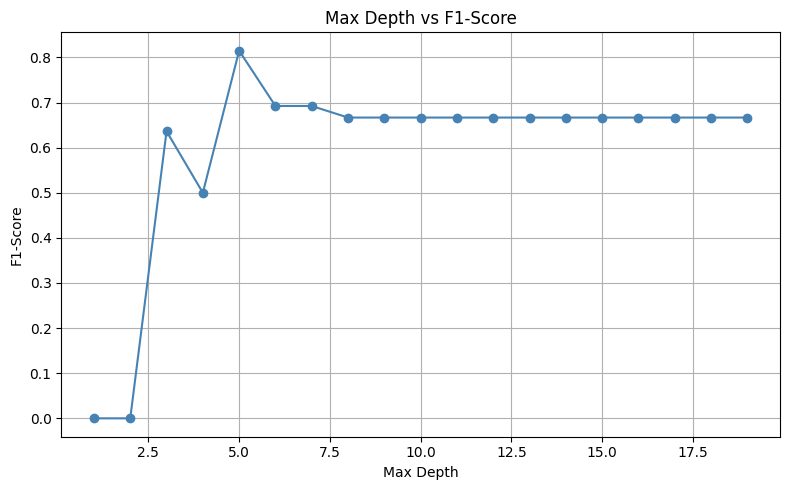

Optimal Max Depth: 5 with F1-Score: 0.8148
--- Depth Complexity Comparison ---
Depth: 3 | Leaves: 5 | F1: 0.6364
Depth: 4 | Leaves: 8 | F1: 0.5000
Depth: 5 | Leaves: 12 | F1: 0.8148
Depth: 6 | Leaves: 19 | F1: 0.6923
Depth: 7 | Leaves: 23 | F1: 0.6923
Depth: 8 | Leaves: 25 | F1: 0.6667
Depth: 9 | Leaves: 25 | F1: 0.6667
Depth: 10 | Leaves: 25 | F1: 0.6667

--- Cross Validation Depth Comparison ---
Depth: 3 | Mean F1: 0.4194 | Std: 0.1410
Depth: 4 | Mean F1: 0.4770 | Std: 0.0630
Depth: 5 | Mean F1: 0.4689 | Std: 0.0921
Depth: 6 | Mean F1: 0.4750 | Std: 0.0874
Depth: 7 | Mean F1: 0.5021 | Std: 0.0939
Depth: 8 | Mean F1: 0.4815 | Std: 0.0738
Depth: 9 | Mean F1: 0.4815 | Std: 0.0738
Depth: 10 | Mean F1: 0.4815 | Std: 0.0738


In [44]:
# Train decision tree with varying max_depth and evaluate F1-score
depths = range(1, 20)
f1_scores = []

# Loop through depths to find the optimal max depth
for depth in depths:
    model_inconsistent = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model_inconsistent.fit(X_train_inconsistent, y_train_inconsistent)
    preds = model_inconsistent.predict(X_test_inconsistent)
    f1_scores.append(f1_score(y_test_inconsistent, preds))

# Plot depth vs F1-score
plt.figure(figsize=(8, 5))
plt.plot(depths, f1_scores, marker="o", color="steelblue")
plt.title("Max Depth vs F1-Score")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Find optimal depth
optimal_depth = depths[f1_scores.index(max(f1_scores))]
print(f"Optimal Max Depth: {optimal_depth} with F1-Score: {max(f1_scores):.4f}")


# Compare depth complexity and F1-score for selected depths
print("--- Depth Complexity Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_inconsistent_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    model_inconsistent_test.fit(X_train_inconsistent, y_train_inconsistent)
    preds = model_inconsistent_test.predict(X_test_inconsistent)
    leaves = model_inconsistent_test.get_n_leaves()
    f1 = f1_score(y_test_inconsistent, preds)
    print(f"Depth: {depth} | Leaves: {leaves} | F1: {f1:.4f}")

# Cross-validation to compare depth performance
print("\n--- Cross Validation Depth Comparison ---")
for depth in [3, 4, 5, 6, 7, 8, 9, 10]:
    model_inconsistent_test = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42)
    cv_scores = cross_val_score(model_inconsistent_test, X_inconsistent, y_inconsistent, cv=5, scoring="f1")
    print(f"Depth: {depth} | Mean F1: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

In [ ]:
# Choose optimal depth = 7 based on cross validation results
optimal_depth = 7

# Train final inconsistent model with optimal depth and evaluate on test set
model_inconsistent = DecisionTreeClassifier(criterion="entropy", max_depth=optimal_depth, random_state=42)
model_inconsistent.fit(X_train_inconsistent, y_train_inconsistent)
print(f"Inconsistent model retrained with max_depth={optimal_depth}")

Inconsistent model retrained with max_depth=7


In [46]:
y_pred_inconsistent = model_inconsistent.predict(X_test)

# Evaluate final model performance
print("--- Model Evaluation ---")
print(f"Accuracy:  {accuracy_score(y_test_inconsistent, y_pred_inconsistent):.4f}")
print(f"F1-Score:  {f1_score(y_test_inconsistent, y_pred_inconsistent):.4f}")
print(f"Precision: {precision_score(y_test_inconsistent, y_pred_inconsistent):.4f}")
print(f"Recall:    {recall_score(y_test_inconsistent, y_pred_inconsistent):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_inconsistent, y_pred_inconsistent,
      target_names=["Not at Risk", "At Risk"]))

--- Model Evaluation ---
Accuracy:  0.8689
F1-Score:  0.6923
Precision: 0.7500
Recall:    0.6429

--- Classification Report ---
              precision    recall  f1-score   support

 Not at Risk       0.90      0.94      0.92        47
     At Risk       0.75      0.64      0.69        14

    accuracy                           0.87        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.86      0.87      0.87        61



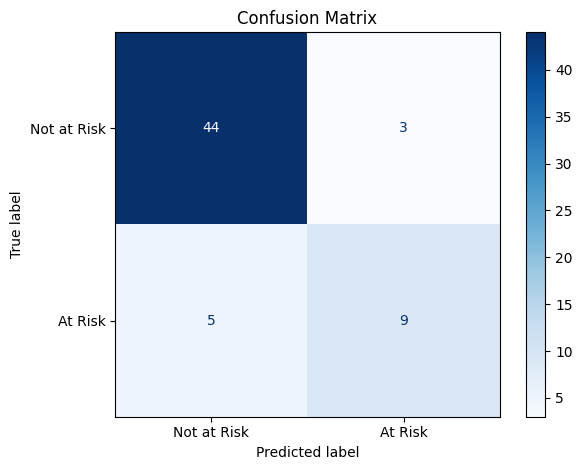

In [47]:
# Confusion Matrix
cm = confusion_matrix(y_test_inconsistent, y_pred_inconsistent)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not at Risk", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [48]:
# Confusion matrix values
TN = 23  # True Negatives
FP = 6   # False Positives
FN = 7   # False Negatives
TP = 25  # True Positives

# Total patients
total = TN + FP + FN + TP

# Accuracy
accuracy = (TP + TN) / total

# Precision
precision = TP / (TP + FP)

# Recall
recall = TP / (TP + FN)

# F1 Score
f1 = 2 * (precision * recall) / (precision + recall)

# Specificity (True Negative Rate)
specificity = TN / (TN + FP)

# False Positive Rate
fpr = FP / (FP + TN)

# False Negative Rate
fnr = FN / (FN + TP)

# Error Rate
error_rate = (FP + FN) / total

print("\n" + "=" * 45)
print("            SUMMARY TABLE")
print("=" * 45)
print(f"{'Metric':<30} {'Value':>8} {'Percentage':>12}")
print("-" * 45)
print(f"{'Accuracy':<30} {accuracy:>8.4f} {accuracy*100:>11.1f}%")
print(f"{'Precision':<30} {precision:>8.4f} {precision*100:>11.1f}%")
print(f"{'Recall (Sensitivity)':<30} {recall:>8.4f} {recall*100:>11.1f}%")
print(f"{'F1-Score':<30} {f1:>8.4f} {f1*100:>11.1f}%")
print(f"{'Specificity':<30} {specificity:>8.4f} {specificity*100:>11.1f}%")
print(f"{'False Positive Rate':<30} {fpr:>8.4f} {fpr*100:>11.1f}%")
print(f"{'False Negative Rate':<30} {fnr:>8.4f} {fnr*100:>11.1f}%")
print(f"{'Error Rate':<30} {error_rate:>8.4f} {error_rate*100:>11.1f}%")

print("\n" + "=" * 45)
print("         CLINICAL INTERPRETATION")
print("=" * 45)
print(f"\nTotal patients tested:      {total}")
print(f"Correctly classified:       {TP + TN} ({((TP+TN)/total)*100:.1f}%)")
print(f"Incorrectly classified:     {FP + FN} ({((FP+FN)/total)*100:.1f}%)")
print(f"\nOf {TP+FN} actual at risk patients:")
print(f"  Correctly caught:         {TP} ({recall*100:.1f}%)")
print(f"  Missed (False Negatives): {FN} ({fnr*100:.1f}%)")
print(f"\nOf {TN+FP} actual not at risk patients:")
print(f"  Correctly cleared:        {TN} ({specificity*100:.1f}%)")
print(f"  False alarms:             {FP} ({fpr*100:.1f}%)")


            SUMMARY TABLE
Metric                            Value   Percentage
---------------------------------------------
Accuracy                         0.7869        78.7%
Precision                        0.8065        80.6%
Recall (Sensitivity)             0.7812        78.1%
F1-Score                         0.7937        79.4%
Specificity                      0.7931        79.3%
False Positive Rate              0.2069        20.7%
False Negative Rate              0.2188        21.9%
Error Rate                       0.2131        21.3%

         CLINICAL INTERPRETATION

Total patients tested:      61
Correctly classified:       48 (78.7%)
Incorrectly classified:     13 (21.3%)

Of 32 actual at risk patients:
  Correctly caught:         25 (78.1%)
  Missed (False Negatives): 7 (21.9%)

Of 29 actual not at risk patients:
  Correctly cleared:        23 (79.3%)
  False alarms:             6 (20.7%)


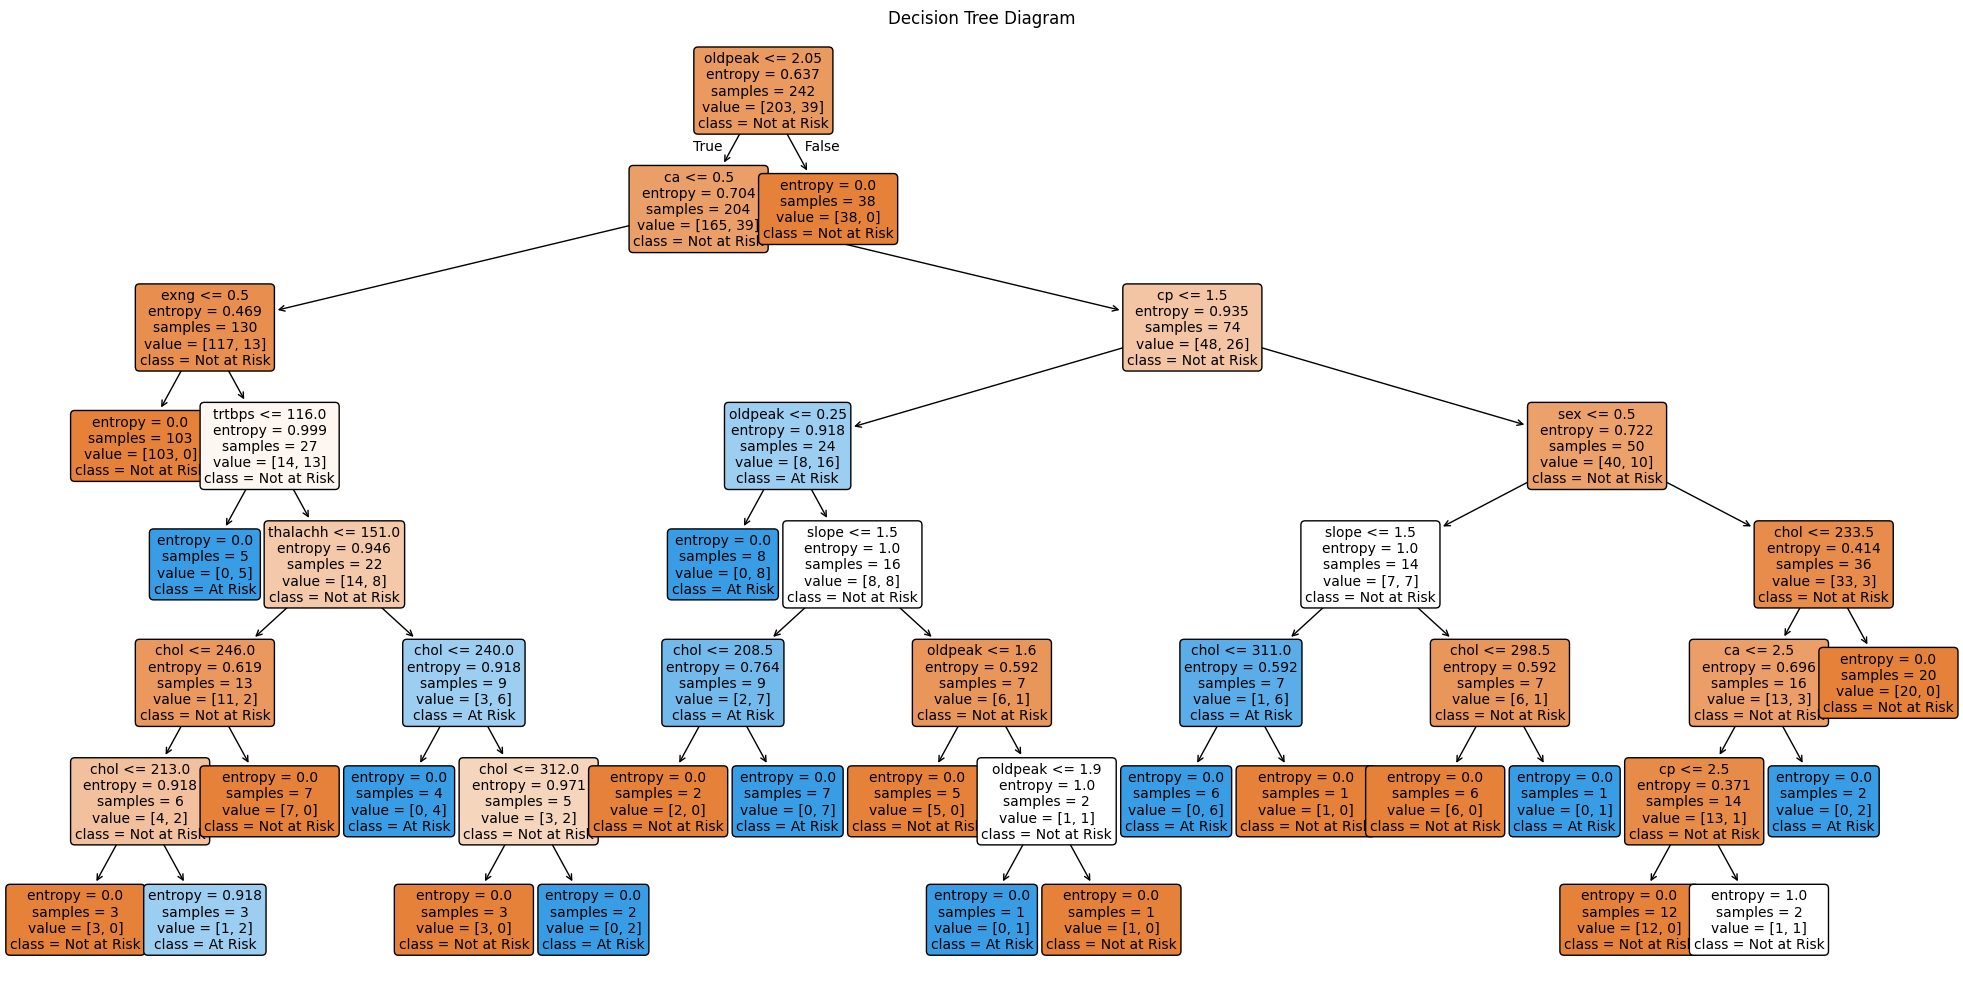

In [49]:
# Decision Tree Diagram
plt.figure(figsize=(20, 10))
plot_tree(
    model_inconsistent,
    feature_names=X.columns,
    class_names=["Not at Risk", "At Risk"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Diagram")
plt.tight_layout()
plt.show()

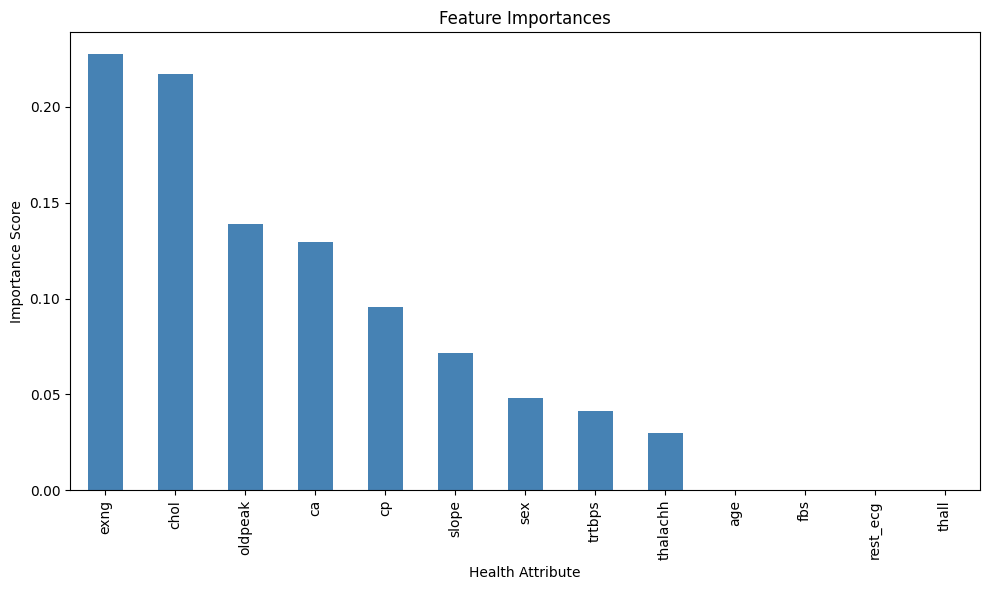

In [50]:
# Feature importance bar chart at optimal depth
importances = pd.Series(model_inconsistent.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar", color="steelblue")
plt.title("Feature Importances")
plt.xlabel("Health Attribute")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [51]:
# Get predicted probabilities for inconsistent model
print("\n--- Patient 1 Prediction for Altered Model ---")
predict_heart_disease_risk(model_inconsistent, X_inconsistent.columns, patient_1)
print("\n--- Patient 2 Prediction for Altered Model ---")
predict_heart_disease_risk(model_inconsistent, X_inconsistent.columns, patient_2)
print("\n--- Patient 3 Prediction for Altered Model ---")
predict_heart_disease_risk(model_inconsistent, X_inconsistent.columns, patient_3)


--- Patient 1 Prediction for Altered Model ---
  Health Attributes:
    age         : 58
    sex         : 1
    cp          : 0
    trtbps      : 140
    chol        : 260
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 145
    exng        : 0
    oldpeak     : 1.5
    slope       : 1
    ca          : 0
    thall       : 2

  Result:     NOT AT RISK for Heart Disease
  Confidence: 100.0%

--- Patient 2 Prediction for Altered Model ---
  Health Attributes:
    age         : 45
    sex         : 0
    cp          : 2
    trtbps      : 125
    chol        : 210
    fbs         : 0
    rest_ecg    : 1
    thalachh    : 165
    exng        : 0
    oldpeak     : 0.5
    slope       : 2
    ca          : 2
    thall       : 1

  Result:     NOT AT RISK for Heart Disease
  Confidence: 100.0%

--- Patient 3 Prediction for Altered Model ---
  Health Attributes:
    age         : 52
    sex         : 1
    cp          : 1
    trtbps      : 145
    chol        : 230
    fbs         : 